In [12]:
from ensembling_for_AIMD import *

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            # nn.Linear(32, 16),
            # nn.ReLU(),
            # nn.Linear(16, 8),
            # nn.ReLU(),
            # nn.Linear(8, 4),
            # nn.ReLU(),
            # nn.Linear(4, 2),
            # nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            # nn.Linear(2, 4),
            # nn.ReLU(),
            # nn.Linear(4, 8),
            # nn.ReLU(),
            # nn.Linear(8, 16),
            # nn.ReLU(),
            # nn.Linear(16, 32),
            # nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

def extract_latent_features(image_list, task, y, epochs=50, batch_size=32, lr=0.001, plot_latentspace=False, plot_regression=False):
    # Extract features using VGG16
    torch.random.manual_seed(32)
    np.random.seed(32)
    torch.random.manual_seed(31)
    np.random.seed(33)

    # torch.manual_seed(0)
    image_tensor = fit_image_dimensions(image_list,task)
    features = extract_features_vgg16(image_tensor)
    input_dim = features.shape[1]
    print("Input Dim:",input_dim)
    autoencoder = Autoencoder(input_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=lr)

    features_tensor = torch.tensor(features, dtype=torch.float32)
    dataset = TensorDataset(features_tensor, features_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Train autoencoder
    for epoch in range(epochs):
        for data in dataloader:
            inputs, _ = data
            optimizer.zero_grad()
            outputs = autoencoder(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()

    # Get latent representation
    with torch.no_grad():
        latent_features = autoencoder.encoder(features_tensor).numpy()
    if plot_latentspace == True:
        plt.figure(figsize=(10, 6))
        sc = plt.scatter(latent_features[:, 0], latent_features[:, 1], c=y, cmap='viridis', alpha=0.5)
        plt.colorbar(sc, label='Energy')
        plt.xlabel('Latent Feature 1')
        plt.ylabel('Latent Feature 2')
        plt.title('Latent Features vs Energy')
        plt.show(block=True)
    return latent_features

def extract_latent_features_without_AE(image_list, task, y, epochs=50, batch_size=32, lr=0.001, plot_latentspace=False, plot_regression=False):
    # Extract features using VGG16
    torch.random.manual_seed(32)
    np.random.seed(32)
    torch.random.manual_seed(31)
    np.random.seed(33)

    # torch.manual_seed(0)
    image_tensor = fit_image_dimensions(image_list,task)
    features = extract_features_vgg16(image_tensor)
    input_dim = features.shape[1]
    print("Input Dim:",input_dim)
    return features
    autoencoder = Autoencoder(input_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=lr)

    features_tensor = torch.tensor(features, dtype=torch.float32)
    dataset = TensorDataset(features_tensor, features_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Train autoencoder
    for epoch in range(epochs):
        for data in dataloader:
            inputs, _ = data
            optimizer.zero_grad()
            outputs = autoencoder(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()

    # Get latent representation
    with torch.no_grad():
        latent_features = autoencoder.encoder(features_tensor).numpy()
    if plot_latentspace == True:
        plt.figure(figsize=(10, 6))
        sc = plt.scatter(latent_features[:, 0], latent_features[:, 1], c=y, cmap='viridis', alpha=0.5)
        plt.colorbar(sc, label='Energy')
        plt.xlabel('Latent Feature 1')
        plt.ylabel('Latent Feature 2')
        plt.title('Latent Features vs Energy')
        plt.show(block=True)
    return latent_features

In [14]:
def training_tree_regressor(image_list, task, energy_to_ind, plot_regression=True):
    latent_features = extract_latent_features(image_list, task, energy_to_ind[task]["target_total_energy_per_atom"])
    energy_data = energy_to_ind[task]["target_total_energy_per_atom"]
    iterations = energy_to_ind[task]["Iteration"]
    # Split dataset into training and testing
    X_train, X_test, y_train, y_test, iterations_train, iterations_test = train_test_split(latent_features, energy_data, iterations, test_size=0.2, shuffle=True, random_state=42)

    # Build a Regression Pipeline with Scaling and Model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])

    # Hyperparameter Tuning
    param_grid = {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [None, 10, 20, 30],
        'regressor__min_samples_split': [2, 5, 10]
    }

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2)
    grid_search.fit(X_train, y_train)
    prediction = grid_search.predict(X_test)

    # Evaluate Model
    best_model = grid_search.best_estimator_

    # Variance Calculation with Random Forest

    random_forest = RandomForestRegressor(
        n_estimators=grid_search.best_params_['regressor__n_estimators'],
        max_depth=grid_search.best_params_['regressor__max_depth'],
        min_samples_split=grid_search.best_params_['regressor__min_samples_split'],
        random_state=42,
        bootstrap=True
    )
    random_forest.fit(X_train, y_train)

    # Obtain predictions from each tree in the forest
    all_train_predictions = np.array([tree.predict(X_train) for tree in random_forest.estimators_])
    all_tree_predictions = np.array([tree.predict(X_test) for tree in random_forest.estimators_])

    # Mean predictions across trees
    train_predictions = np.mean(all_train_predictions, axis=0)
    test_predictions = np.mean(all_tree_predictions, axis=0)

    # Calculate variance (or standard deviation) across predictions
    train_prediction_variance = np.var(all_train_predictions, axis=0)
    prediction_variance = np.var(all_tree_predictions, axis=0)
    prediction_std_dev = np.sqrt(prediction_variance)

    print("Best Model:", best_model)
    y_mean = train_predictions #best_model.predict(X_train)
    y_pred = test_predictions #best_model.predict(X_test)

    # Calculate Evaluation Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Mean Squared Error: {mse}')
    print(f'R2 Score: {r2}')
    if plot_regression == True:
        # Optional: Plotting Predicted vs True Values
        plt.scatter(iterations_train,y_train, c='r', marker='*', alpha=0.5, label="Train - True")
        plt.scatter(iterations_train, y_mean, c="b", marker='*', alpha=0.5, label="Train - Predicted")
        plt.scatter(iterations_test,y_test, c='r', marker='D', alpha=0.5, label="Test - True")
        plt.scatter(iterations_test, y_pred, c="b", marker='D', alpha=0.5, label="Test - Predicted")
        plt.xlabel('Values')
        plt.ylabel('True vs Predicted Values')
        plt.title('True vs Predicted Energy Values for Task ' + str(task))
        plt.legend()
        # if not os.path.exists(f"{cwd_path}/results/tree_regressor/"):
        #     os.makedirs(f"{cwd_path}/results/tree_regressor/")
        # plt.savefig(f"{cwd_path}/results/tree_regressor/true_vs_predicted_task{task}.png")
        plt.show(block=True)
        plt.clf()
    return grid_search, train_predictions, test_predictions, train_prediction_variance, prediction_variance



In [15]:
def cropping_image(image_list, mask_list):
    #crop out the empty spaces
    cropped_image_list = []
    cropped_mask_list = []

    for i in range(0,len(image_list)):
        local_cropped_imglist = []
        local_cropped_masklist = []
        for j in range(0,len(image_list[i])):
            local_cropped_imglist.append(image_list[i][j][:208,0:208])
            local_cropped_masklist.append(mask_list[i][j][:208,0:208])

        cropped_image_list.append(np.array(local_cropped_imglist))
        cropped_mask_list.append(np.array(local_cropped_masklist))

    print("Number of tasks : ",len(cropped_image_list))
    cropped_image_list = np.array(cropped_image_list, dtype=object)
    cropped_mask_list = np.array(cropped_mask_list, dtype=object)
    return np.array(cropped_image_list), np.array(cropped_mask_list)


In [16]:
ind_to_val, image_list, mask_list, label_list, coordinates = data_load()

Data loaded from /lustre/saranath/Techcon24/AIMD/Sim2Experiment/processed_mds/image_energy_data/


In [17]:
cropped_image_list, cropped_mask_list = cropping_image(image_list, mask_list)

energy_to_ind = energy_data(ind_to_val)

Number of tasks :  25
0
Total number of atoms: 103
Last trajectory Number: 2280.0
Total number of atoms: 103
Last trajectory Number: 2150.0
1
Total number of atoms: 83
Last trajectory Number: 2420.0
Total number of atoms: 83
Last trajectory Number: 2460.0
2
Total number of atoms: 88
Last trajectory Number: 2480.0
Total number of atoms: 88
Last trajectory Number: 2590.0
3
Total number of atoms: 94
Last trajectory Number: 2380.0
Total number of atoms: 94
Last trajectory Number: 2340.0
4
Total number of atoms: 85
Last trajectory Number: 2400.0
Total number of atoms: 85
Last trajectory Number: 2580.0
5
Total number of atoms: 89
Last trajectory Number: 2460.0
Total number of atoms: 89
Last trajectory Number: 2440.0
6
Total number of atoms: 102
Last trajectory Number: 2150.0
Total number of atoms: 102
Last trajectory Number: 2030.0
7
Total number of atoms: 93
Last trajectory Number: 2210.0
Total number of atoms: 93
Last trajectory Number: 2430.0
8
Total number of atoms: 86
Last trajectory Nu

(443, 208, 208)
(488, 208, 208)


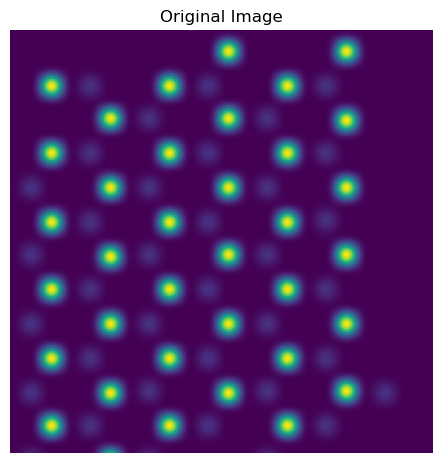

Input Dim: 25088


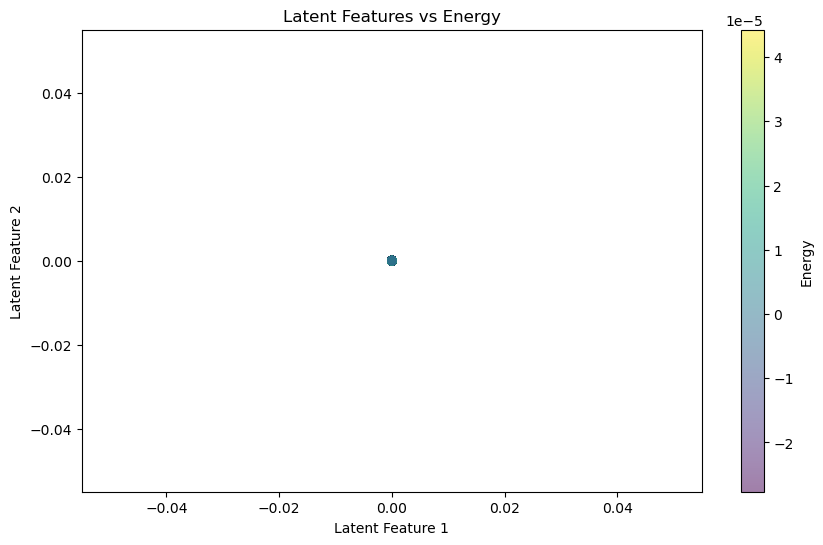

(507, 208, 208)
(472, 208, 208)
(498, 208, 208)
(490, 208, 208)
(418, 208, 208)
(464, 208, 208)
(510, 208, 208)
(495, 208, 208)
(274, 208, 208)
(446, 208, 208)
(446, 208, 208)
(483, 208, 208)
(491, 208, 208)
(404, 208, 208)
(495, 208, 208)
(410, 208, 208)
(452, 208, 208)
(488, 208, 208)
(522, 208, 208)
(398, 208, 208)
(460, 208, 208)
(408, 208, 208)
(457, 208, 208)


In [18]:
import PIL
for task in range(25):
    print(cropped_image_list[task].shape)
    if task != 1:
        continue
    # Get the original image and the corresponding features
    original_image = cropped_image_list[task][0]
    # Plot the original image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title('Original Image')
    plt.axis('off')
    plt.show(block=True)

    latent_features = extract_latent_features(cropped_image_list, task, energy_to_ind[task]["target_total_energy_per_atom"], plot_latentspace=True)                                       
    # grid_search, train_predictions, test_predictions, train_prediction_variance, prediction_variance = training_tree_regressor(cropped_image_list, task, energy_to_ind, plot_regression=True)

In [7]:
from PIL import Image, ImageSequence
import os
cwd_path = os.getcwd()
# Paths to the uploaded images
image_paths = [
    f"{cwd_path}/latent_space_image_analysis/image.png",
    f"{cwd_path}/latent_space_image_analysis/image_1.png",
    f"{cwd_path}/latent_space_image_analysis/image_2.png",
    f"{cwd_path}/latent_space_image_analysis/image_3.png",
    f"{cwd_path}/latent_space_image_analysis/image_4.png"
]

# Load images
images = [Image.open(path) for path in image_paths[::-1]]

# Create GIF
gif_path = f"{cwd_path}/latent_space_image_analysis/latent_features_vs_energy.gif"
images[0].save(
    gif_path,
    save_all=True,
    append_images=images[1:],
    duration=2000,  # Duration for each frame in milliseconds
    loop=0  # Loop indefinitely
)


# ""

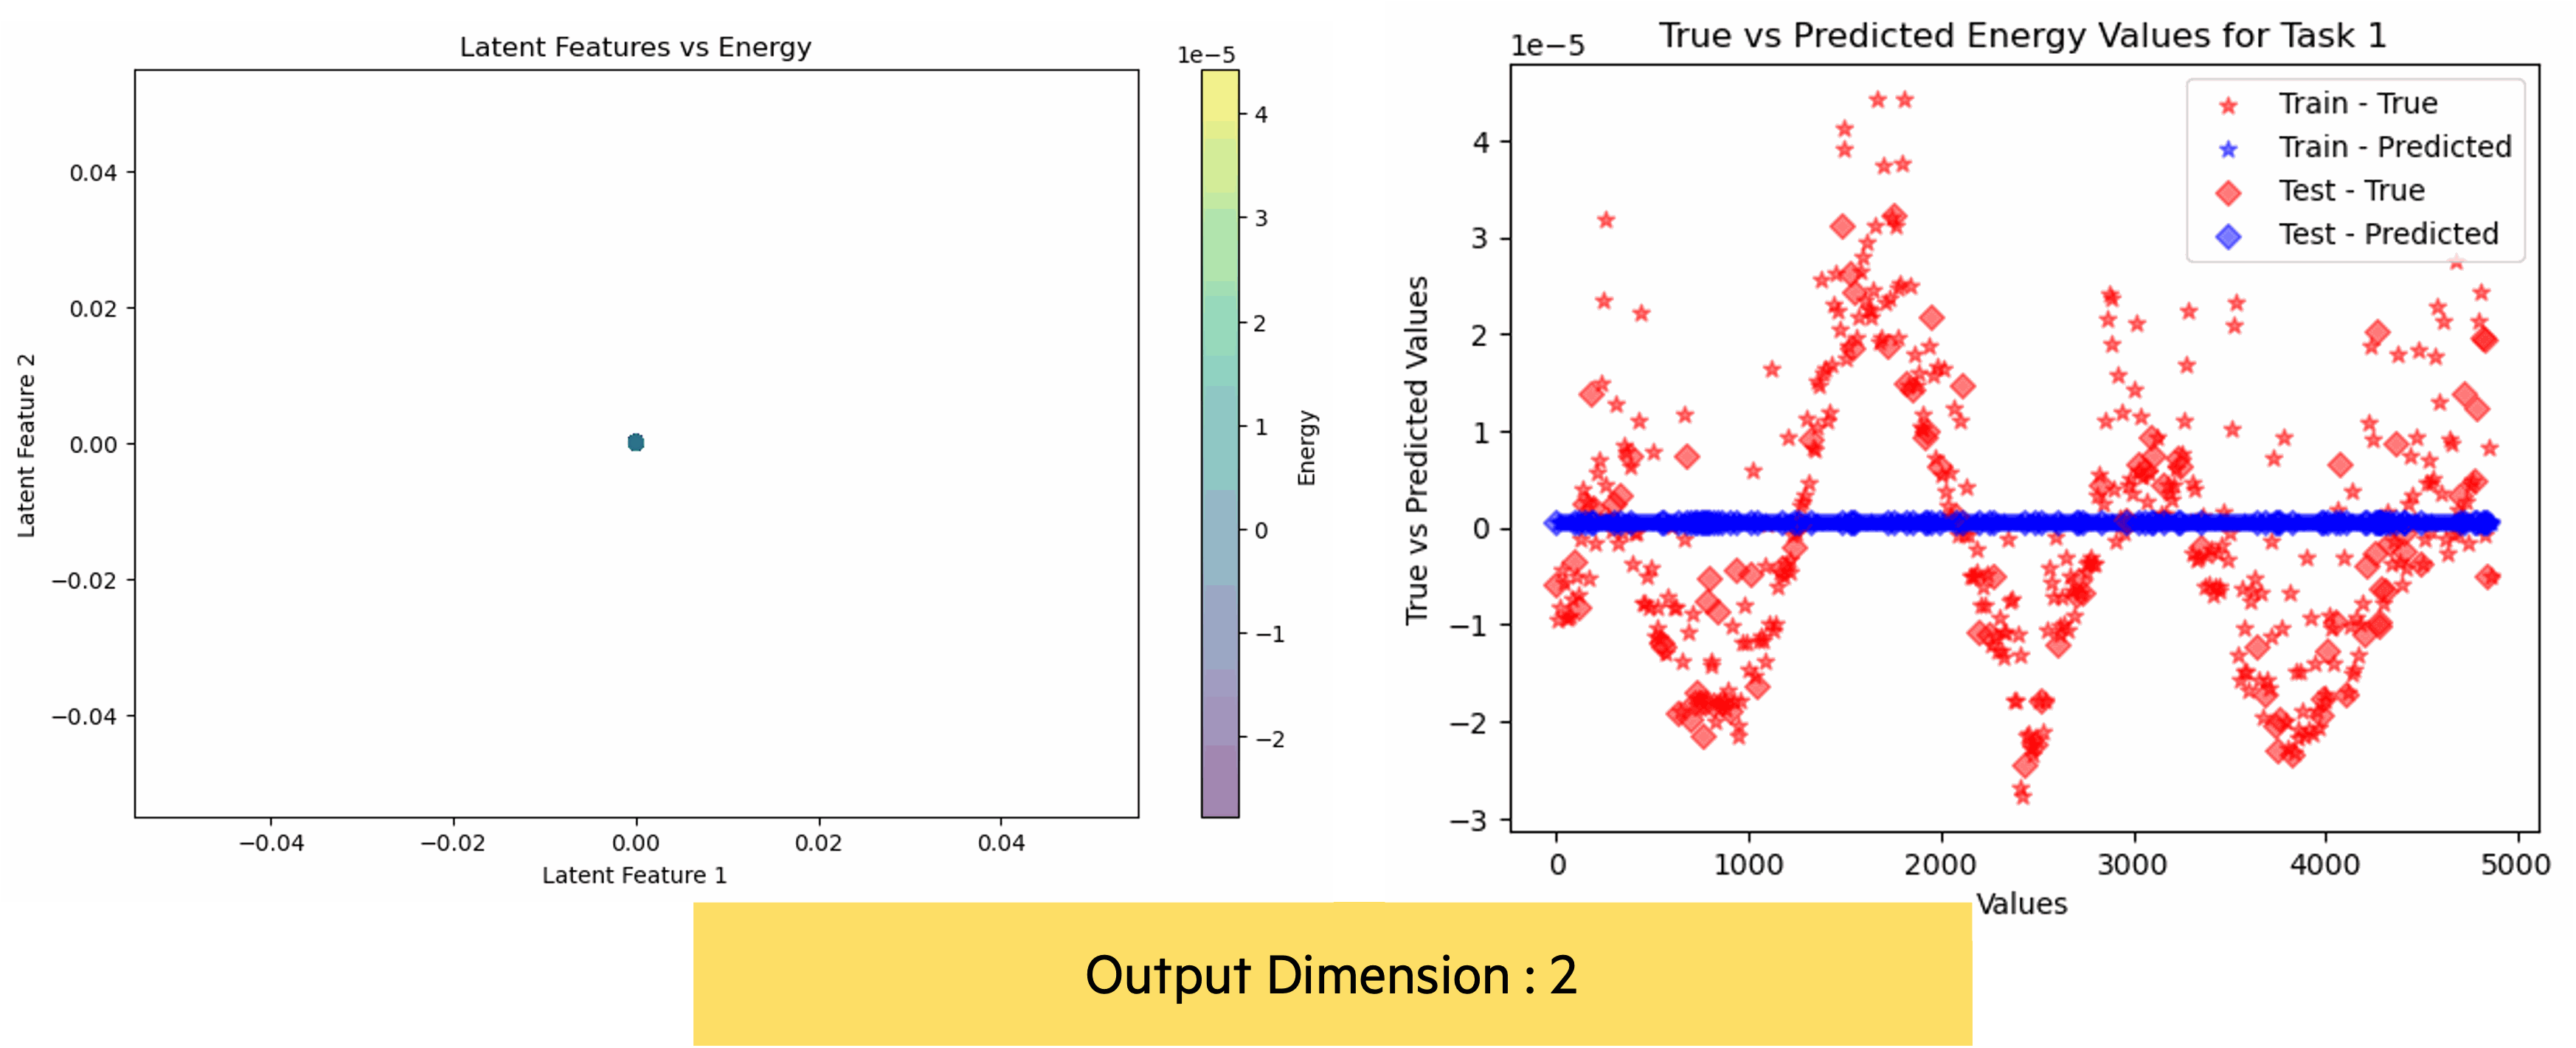

In [8]:
from IPython.display import Image as IPImage, display

# Display the GIF
display(IPImage(filename=gif_path))

## Gaussian Mixture of Models

In [8]:
import numpy as np
from sklearn.mixture import GaussianMixture

def fit_gmm(X, Y, n_components=3, random_state=42):
    """
    Fit a Gaussian Mixture Model to the joint distribution of X and Y.
    X: shape (n_samples, n_features_x)
    Y: shape (n_samples, n_features_y)
    """
    # Concatenate X and Y along features to get joint data
    XY = np.hstack((X, Y))
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=random_state, reg_covar=1e-4)
    gmm.fit(XY)
    return gmm

def gmr_predict(gmm, x_query):
    """
    Gaussian Mixture Regression prediction.
    Given a trained GMM over [X, Y], and a query point x_query (shape (n_features_x,)),
    this function returns the conditional mean and covariance of Y given X = x_query.
    """
    # Extract parameters
    weights = gmm.weights_
    means = gmm.means_
    covariances = gmm.covariances_

    # Dimensions
    D = means.shape[1]  # total dimension (X + Y)
    n_components = gmm.n_components

    # Assume we know how we split X and Y in the original data
    # Let's say X had dX features, Y had dY features
    # If you know the dimensionalities:
    dX = x_query.shape[0]
    dY = D - dX

    # Ensure x_query is a row vector
    x_query = x_query.reshape(1, -1)

    # For each component, extract means and covariances
    # Partition them into X and Y parts
    mus_x = means[:, :dX]
    mus_y = means[:, dX:]
    
    Sigmas = covariances
    # Partition covariances
    # Sigma_k = [[Sigma_xx_k, Sigma_xy_k],
    #            [Sigma_yx_k, Sigma_yy_k]]
    Sigma_xx = np.zeros((n_components, dX, dX))
    Sigma_xy = np.zeros((n_components, dX, dY))
    Sigma_yx = np.zeros((n_components, dY, dX))
    Sigma_yy = np.zeros((n_components, dY, dY))
    
    for k in range(n_components):
        Sigma_xx[k] = Sigmas[k][:dX, :dX]
        Sigma_xy[k] = Sigmas[k][:dX, dX:]
        Sigma_yx[k] = Sigmas[k][dX:, :dX]
        Sigma_yy[k] = Sigmas[k][dX:, dX:]

    # Compute component responsibilities for given x_query
    # p(x|k) = N(x; mus_x[k], Sigma_xx[k])
    # Then h_k(x) = pi_k * p(x|k) / sum_j pi_j p(x|j)
    # We'll use the conditional probabilities:
    p_x_given_k = np.array([
        weights[k] * _gaussian_pdf(x_query, mus_x[k], Sigma_xx[k])
        for k in range(n_components)
    ])
    h = p_x_given_k / np.sum(p_x_given_k)

    # Now compute conditional means and covariances for Y given X=x_query
    # mu_y|x = mu_y + Sigma_yx * Sigma_xx^{-1} (x - mu_x)
    # Sigma_y|x = Sigma_yy - Sigma_yx * Sigma_xx^{-1} Sigma_xy
    conditional_means = []
    conditional_covs = []
    for k in range(n_components):
        inv_Sigma_xx = np.linalg.inv(Sigma_xx[k])
        diff = (x_query - mus_x[k])  # shape (1, dX)
        mu_y_given_x = mus_y[k] + (Sigma_yx[k] @ inv_Sigma_xx @ diff.T).T
        Sigma_y_given_x = Sigma_yy[k] - Sigma_yx[k] @ inv_Sigma_xx @ Sigma_xy[k]
        
        conditional_means.append(mu_y_given_x.ravel())
        conditional_covs.append(Sigma_y_given_x)

    # Combine components using h
    # Mean of mixture: sum_k h_k * mu_y|x(k)
    mu_mix = sum(h[k] * conditional_means[k] for k in range(n_components))
    # Cov of mixture: sum_k h_k [Sigma_y|x(k) + mu_y|x(k)*mu_y|x(k)^T] - mu_mix*mu_mix^T
    # This is the mixture covariance formula
    Sigma_mix = np.zeros((dY, dY))
    for k in range(n_components):
        diff_mu = (conditional_means[k] - mu_mix).reshape(-1,1)
        Sigma_mix += h[k] * (conditional_covs[k] + diff_mu @ diff_mu.T)

    return mu_mix, Sigma_mix, weights

def _gaussian_pdf(x, mean, cov):
    """
    Compute probability density of a multivariate Gaussian at points x.
    x: shape (1, d)
    mean: shape (d,)
    cov: shape (d,d)
    """
    d = mean.shape[0]
    diff = x - mean
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * np.einsum('ij,jk,ik->i', diff, inv_cov, diff)
    denom = np.sqrt((2 * np.pi)**d * np.linalg.det(cov))
    return np.exp(exponent) / denom


With Autoencoder

Input Dim: 25088
Latent Features Shape: (488, 32)
Time taken to predict train data: 0.24550700187683105
Train MSE for task 1 : 1.1870803114098348e-10
Test MSE for task 1 : 0.15754192248342588
R-squared (R²) Score: 0.1282960894258095


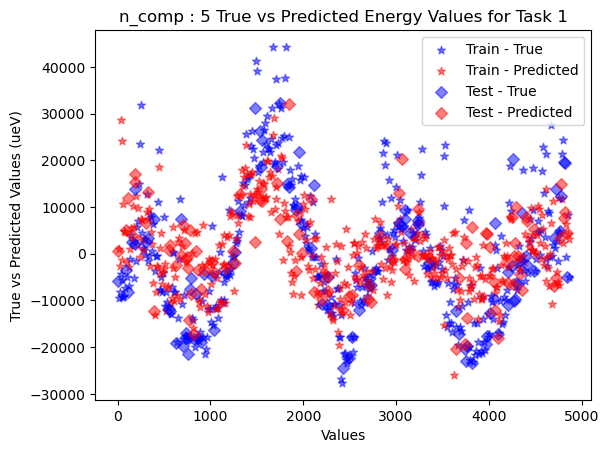

In [11]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy.stats import norm
import time

n_components = list(range(5,6))
test_results = []
test_mse = []
plot_regression = True
for task in range(1,2):
   latent_features = extract_latent_features(cropped_image_list, task, energy_to_ind[task]["target_total_energy_per_atom"])
   iterations = energy_to_ind[task]["Iteration"]


   print("Latent Features Shape:", latent_features.shape)
   # Split dataset into training and testing
   energy_data = np.array(energy_to_ind[task]["target_total_energy_per_atom"]).reshape(-1,1)
   X_train, X_test, y_train, y_test, iterations_train, iterations_test = train_test_split(latent_features, energy_data, iterations, test_size=0.2, shuffle=True, random_state=42)
   for n_comp in n_components:
     #X, Y = cropped_image_list[task][:int(0.8*len(cropped_image_list[task]))], energy_to_ind[task]["target_total_energy_per_atom"][:int(0.8*len(cropped_image_list[task]))]
     #x_test, y_test = cropped_image_list[task][int(0.8*len(cropped_image_list[task])):], energy_to_ind[task]["target_total_energy_per_atom"][int(0.8*len(cropped_image_list[task])):]

     gmm = fit_gmm(X_train, y_train, n_components=n_comp)
     Y_means = []
     Y_sigmas = []
     start = time.time()
     for i in range(X_train.shape[0]):
      x_query = X_train[i, :]  # single sample
      y_mean, y_sigma, _ = gmr_predict(gmm, x_query)
      Y_means.append(y_mean)
      Y_sigmas.append(y_sigma)
     end = time.time()
     print("Time taken to predict train data:", end-start)
     Y_means = np.array(Y_means)
     Y_means = np.nan_to_num(Y_means)
     mse = mean_squared_error(y_train, Y_means)
     print("Train MSE for task", task, ":", mse)
     
     #y_mean, y_sigma = gmr_predict(gmm, X)
     mu_y = []
     Sigma_y = []
     weights = []
     for i in range(X_test.shape[0]):
      x_query = X_test[i, :]  # single sample
      y_mean, y_sigma, weight = gmr_predict(gmm, x_query)
      mu_y.append(y_mean)
      Sigma_y.append(y_sigma)
      
     mu_y = np.array(mu_y)
     Sigma_y = np.array(Sigma_y)
     # fill na with mean
     mu_y = np.nan_to_num(mu_y)
     #mu_y, Sigma_y = gmr_predict(gmm, x_query)
     mse = mean_squared_error(y_test, mu_y)
     print("Test MSE for task", task, ":", mse/1e-9)
     r2 = r2_score(y_test, mu_y)
     print("R-squared (R²) Score:", r2)
     test_results.append(r2)
     test_mse.append(mse)
     if plot_regression == True:
        # Optional: Plotting Predicted vs True Values
        plt.scatter(iterations_train,[val/1e-9 for val in y_train], c='b', marker='*', alpha=0.5, label="Train - True")
        plt.scatter(iterations_train, [val/1e-9 for val in Y_means], c="r", marker='*', alpha=0.5, label="Train - Predicted")
        plt.scatter(iterations_test,[val/1e-9 for val in y_test] , c='b', marker='D', alpha=0.5, label="Test - True")
        plt.scatter(iterations_test, [val/1e-9 for val in mu_y], c="r", marker='D', alpha=0.5, label="Test - Predicted")
        plt.xlabel('Values')
        plt.ylabel('True vs Predicted Values (ueV)')
        plt.title(f'n_comp : {n_comp} True vs Predicted Energy Values for Task ' + str(task))
        plt.legend()
        plt.show()
     break
     #    if not os.path.exists(f"{cwd_path}/results/tree_regressor/"):
     #        os.makedirs(f"{cwd_path}/results/tree_regressor/")
     #    plt.savefig(f"{cwd_path}/results/tree_regressor/true_vs_predicted_task{task}.png")
     #    plt.clf()
   
     #= extract_latent_features(cropped_image_list, task, energy_to_ind[task]["target_total_energy_per_atom"], plot_latentspace=True)

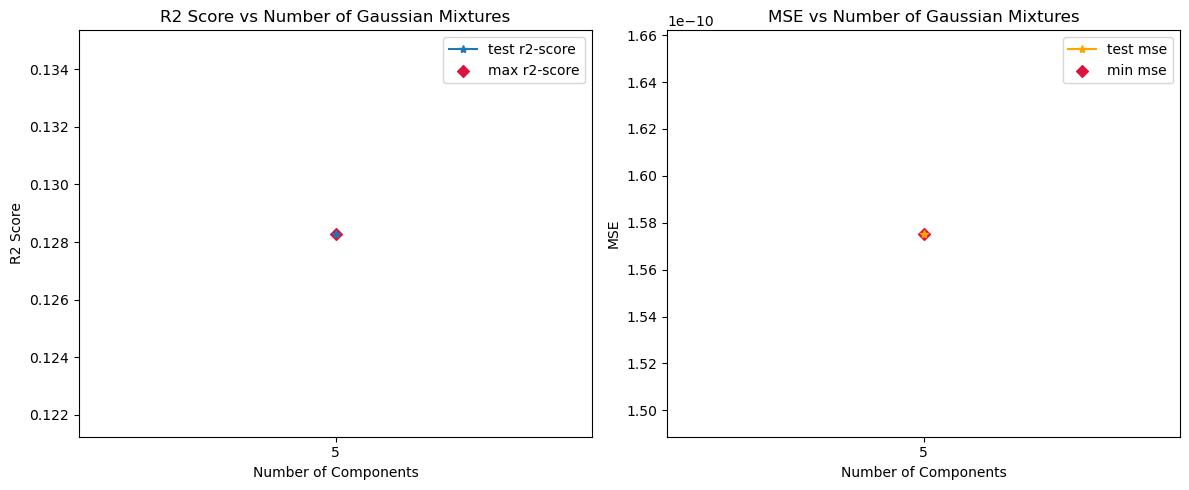

Finally Selected Number of Components: 5


In [10]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot R2 score in the first subplot
ax[0].plot(n_components, test_results, marker='*', label="test r2-score")
ax[0].scatter(n_components[np.argmax(test_results)], max(test_results), c='crimson', marker="D", label='max r2-score')
ax[0].set_xticks(n_components)
ax[0].legend()
ax[0].set_xlabel('Number of Components')
ax[0].set_ylabel('R2 Score')
ax[0].set_title('R2 Score vs Number of Gaussian Mixtures')

# Plot MSE in the second subplot
ax[1].plot(n_components, test_mse, marker='*', c="orange", label="test mse")
ax[1].scatter(n_components[np.argmin(test_mse)], min(test_mse), c='crimson', marker="D", label='min mse')
ax[1].set_xticks(n_components)
ax[1].legend()
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('MSE')
ax[1].set_title('MSE vs Number of Gaussian Mixtures')

# Adjust layout and show the plot
plt.tight_layout()
plt.show(block=True)

selected_ncomp = n_components[np.argmax(test_results)]
print("Finally Selected Number of Components:", selected_ncomp)

Without Autoencoder

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy.stats import norm

n_components = list(range(5,6))
selected_ncomp = 5
test_results = []
test_mse = []
plot_regression = True
for task in range(1,25):
   latent_features = extract_latent_features_without_AE(cropped_image_list, task, energy_to_ind[task]["target_total_energy_per_atom"])
   iterations = energy_to_ind[task]["Iteration"]


   print("Latent Features Shape:", latent_features.shape)
   # Split dataset into training and testing
   energy_data = np.array(energy_to_ind[task]["target_total_energy_per_atom"]).reshape(-1,1)
   X_train, X_test, y_train, y_test, iterations_train, iterations_test = train_test_split(latent_features, energy_data, iterations, test_size=0.2, shuffle=True, random_state=42)
   for n_comp in n_components:
     #X, Y = cropped_image_list[task][:int(0.8*len(cropped_image_list[task]))], energy_to_ind[task]["target_total_energy_per_atom"][:int(0.8*len(cropped_image_list[task]))]
     #x_test, y_test = cropped_image_list[task][int(0.8*len(cropped_image_list[task])):], energy_to_ind[task]["target_total_energy_per_atom"][int(0.8*len(cropped_image_list[task])):]

     gmm = fit_gmm(X_train, y_train, n_components=n_comp)
     Y_means = []
     Y_sigmas = []
     for i in range(X_train.shape[0]):
      x_query = X_train[i, :]  # single sample
      y_mean, y_sigma, _ = gmr_predict(gmm, x_query)
      Y_means.append(y_mean)
      Y_sigmas.append(y_sigma)
     Y_means = np.array(Y_means)
     mse = mean_squared_error(y_train, Y_means)
     print("Train MSE for task", task, ":", mse)
     
     #y_mean, y_sigma = gmr_predict(gmm, X)
     mu_y = []
     Sigma_y = []
     weights = []
     for i in range(X_test.shape[0]):
      x_query = X_test[i, :]  # single sample
      y_mean, y_sigma, weight = gmr_predict(gmm, x_query)
      mu_y.append(y_mean)
      Sigma_y.append(y_sigma)
      
     mu_y = np.array(mu_y)
     Sigma_y = np.array(Sigma_y)
     # fill na with mean
     mu_y = np.nan_to_num(mu_y)
     #mu_y, Sigma_y = gmr_predict(gmm, x_query)
     mse = mean_squared_error(y_test, mu_y)
     print("Test MSE for task", task, ":", mse/1e-9)
     r2 = r2_score(y_test, mu_y)
     print("R-squared (R²) Score:", r2)
     test_results.append(r2)
     test_mse.append(mse)
     if plot_regression == True:
        # Optional: Plotting Predicted vs True Values
        plt.scatter(iterations_train,y_train, c='r', marker='*', alpha=0.5, label="Train - True")
        plt.scatter(iterations_train, Y_means, c="b", marker='*', alpha=0.5, label="Train - Predicted")
        plt.scatter(iterations_test,y_test, c='r', marker='D', alpha=0.5, label="Test - True")
        plt.scatter(iterations_test, mu_y, c="b", marker='D', alpha=0.5, label="Test - Predicted")
        plt.xlabel('Values')
        plt.ylabel('True vs Predicted Values')
        plt.title(f'n_comp : {n_comp} True vs Predicted Energy Values for Task ' + str(task))
        plt.legend()
        plt.show()
     #    if not os.path.exists(f"{cwd_path}/results/tree_regressor/"):
     #        os.makedirs(f"{cwd_path}/results/tree_regressor/")
     #    plt.savefig(f"{cwd_path}/results/tree_regressor/true_vs_predicted_task{task}.png")
     #    plt.clf()
   break
     #= extract_latent_features(cropped_image_list, task, energy_to_ind[task]["target_total_energy_per_atom"], plot_latentspace=True)

Input Dim: 25088
Latent Features Shape: torch.Size([488, 25088])


KeyboardInterrupt: 

## Active Learning with GMMs

In [20]:
def select_most_uncertain_samples(predicted_variance, num_samples=1):
    # Switch the model to evaluation mode
    # Use the model to predict the unlabeled data
    # with torch.no_grad():
    #   mean, variance = model.predict(unlabeled_features)

    # Compute uncertainties (variances) for each prediction
    uncertainties = torch.tensor(predicted_variance)

    # Select the indices of the `num_samples` most uncertain predictions
    _, most_uncertain_indices = torch.topk(uncertainties, num_samples)

    return most_uncertain_indices

def select_most_uncertain_samples(predicted_variance, num_samples=1):
    # Switch the model to evaluation mode
    # Use the model to predict the unlabeled data
    # with torch.no_grad():
    #   mean, variance = model.predict(unlabeled_features)

    # Compute uncertainties (variances) for each prediction
    uncertainties = torch.tensor(predicted_variance)

    # Select the indices of the `num_samples` most uncertain predictions
    _, most_uncertain_indices = torch.topk(uncertainties, num_samples)

    return most_uncertain_indices

def plot_images_by_indices(images, indices, true_labels, iteration, task_id, exp_step, acquisition, cols=5):
    """Plot images corresponding to the specified indices."""
    num_images = len(images)
    rows = num_images // cols + (1 if num_images % cols else 0)

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, 5))

    for idx in range(num_images):
      img_ax = plt.subplot(rows, cols, idx+1)
      img_ax.imshow(images[idx])
      img_ax.set_title(f"Iteration: {iteration[indices[idx]]}",fontsize=30)
      img_ax.axis('off')

    '''
    scatter_ax = axs[cols-1]
    scatter_ax.set_title('Energy at Optimal Iteration Plot - Active Learning Exploration')
    scatter_ax.set_xlabel('Iteration')
    scatter_ax.set_ylabel('Energy')
    for index in indices:
      scatter_ax.scatter(iteration[index], true_labels[index], color='red', s=100, marker=f"${int(iteration[index])}$")  # Increase marker size with `s`
    '''
    plt.tight_layout()
    if not os.path.exists(f"{cwd_path}/results/tree_regressor/active_learning/AL_selected_Simulated_images/task{task_id+1}/"):
        os.makedirs(f"{cwd_path}/results/tree_regressor/active_learning/AL_selected_Simulated_images/task{task_id+1}/")
    plt.savefig(f"{cwd_path}/results/tree_regressor/active_learning/AL_selected_Simulated_images/task{task_id+1}/selected_exp{exp_step}_with_{acquisition}acq_trajectory.png")
    plt.clf()

# @title modified graph utility functions for AL plots
def mod_plot_selected_points(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations):
    plt.figure(figsize=(12, 8))

    # Scatter plot for ground truth
    plt.scatter(
        iterations_test.cpu(),
        [yval//1e-6 for yval in test_y.cpu()],
        marker="o",
        color='royalblue',
        s=100,  # Marker size
        edgecolor='k',
        label='Ground Truth'
    )

    # Scatter plot for predictions
    plt.scatter(
        selected_iter,
        [energy/1e-6 for energy in selected_energy],
        s=150,  # Larger marker size
        color='crimson',
        marker='D',
        edgecolor='k',
        label='Selected Points'
    )

    # Add titles and labels with enhanced styles
    # plt.title(
    #     f"Selected Points through Active Learning with {acquisition} Acquisition Function",
    #     fontsize=24,
    #     fontweight='bold',
    #     color='darkblue'
    # )
    plt.xlabel(
        "Iterations (fs)",
        fontsize=18,
        fontweight='bold'
    )
    plt.ylabel(
        "Target Energy Difference per Atom (ueV)",
        fontsize=18,
        fontweight='bold'
    )

    # Adjust x and y axis ticks
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')

    # Add a grid for better readability
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a legend with enhanced styles
    plt.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True)

    # Adjust layout to ensure everything fits well
    plt.tight_layout()

    # Optionally save the plot
    if not os.path.exists(f"{cwd_path}/results/GMM/single_tasks/active_learning/task{task+1}/"):
        os.makedirs(f"{cwd_path}/results/GMM/single_tasks/active_learning/task{task+1}/")
    plt.savefig(f"{cwd_path}/results/GMM/single_tasks/active_learning/task{task+1}/final_actively_selected_{num_iterations}_points_with_{acquisition}_acq.png")
    plt.show(block=True)
    plt.clf()

def plot_images_by_indices(images, indices, true_labels, iteration, task_id, exp_step, acquisition, cols=5):
    """Plot images corresponding to the specified indices."""
    num_images = len(images)
    rows = num_images // cols + (1 if num_images % cols else 0)

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, 5))

    for idx in range(num_images):
      img_ax = plt.subplot(rows, cols, idx+1)
      img_ax.imshow(images[idx])
      img_ax.set_title(f"Iteration: {iteration[indices[idx]]}",fontsize=30)
      img_ax.axis('off')

    '''
    scatter_ax = axs[cols-1]
    scatter_ax.set_title('Energy at Optimal Iteration Plot - Active Learning Exploration')
    scatter_ax.set_xlabel('Iteration')
    scatter_ax.set_ylabel('Energy')
    for index in indices:
      scatter_ax.scatter(iteration[index], true_labels[index], color='red', s=100, marker=f"${int(iteration[index])}$")  # Increase marker size with `s`
    '''
    plt.tight_layout()
    if not os.path.exists(f"{cwd_path}/results/GMM/active_learning/AL_selected_Simulated_images/task{task_id+1}/"):
        os.makedirs(f"{cwd_path}/results/GMM/active_learning/AL_selected_Simulated_images/task{task_id+1}/")
    plt.savefig(f"{cwd_path}/results/GMM/active_learning/AL_selected_Simulated_images/task{task_id+1}/selected_exp{exp_step}_with_{acquisition}acq_trajectory.png")
    plt.clf()


In [21]:
def gmm_mod_plot_al_training_loss(training_loss, task, num_iterations, acquisition):
    plt.figure(figsize=(12, 8))

    # Plot the training loss with enhancements
    plt.plot(
        [val/1e-9 for val in training_loss],
        color='darkblue',
        linestyle='-',
        marker='o',
        markersize=8,
        linewidth=2,
        label='Loss'
    )

    # Add titles and labels with enhanced styles
    plt.title(
        f"Active Learning Test Loss for Task {task} - {num_iterations} Exploration Steps",
        fontsize=24,
        fontweight='bold',
        color='darkblue'
    )
    plt.xlabel(
        "Exploration Steps",
        fontsize=18,
        fontweight='bold'
    )
    plt.ylabel(
        "Active Learning Error (nano eV)",
        fontsize=18,
        fontweight='bold'
    )

    # Adjust x-axis ticks
    plt.xticks(
        fontsize=14,
        fontweight='bold'
    )

    # Adjust y-axis ticks
    plt.yticks(
        fontsize=14,
        fontweight='bold'
    )

    # Add grid lines for better readability
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a legend
    plt.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True)

    # Optionally save the plot
    # plt.savefig(f"result/active_learning/{acquisition}/Training_loss_task{task+1}.png")
    plt.savefig(f"{cwd_path}/results/GMM/single_tasks/active_learning/task{task+1}/Training_loss_{acquisition}_acq.png")
    plt.tight_layout()
    
    plt.clf()

def tree_mod_plot_al_training_loss(training_loss, task, num_iterations, acquisition):
    plt.figure(figsize=(12, 8))

    # Plot the training loss with enhancements
    plt.plot(
        [val/1e-9 for val in training_loss],
        color='darkblue',
        linestyle='-',
        marker='o',
        markersize=8,
        linewidth=2,
        label='Loss'
    )

    # Add titles and labels with enhanced styles
    plt.title(
        f"Active Learning Test Loss for Task {task} - {num_iterations} Exploration Steps",
        fontsize=24,
        fontweight='bold',
        color='darkblue'
    )
    plt.xlabel(
        "Exploration Steps",
        fontsize=18,
        fontweight='bold'
    )
    plt.ylabel(
        "Active Learning Error (nano eV)",
        fontsize=18,
        fontweight='bold'
    )

    # Adjust x-axis ticks
    plt.xticks(
        fontsize=14,
        fontweight='bold'
    )

    # Adjust y-axis ticks
    plt.yticks(
        fontsize=14,
        fontweight='bold'
    )

    # Add grid lines for better readability
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a legend
    plt.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True)

    # Optionally save the plot
    # plt.savefig(f"result/active_learning/{acquisition}/Training_loss_task{task+1}.png")
    plt.savefig(f"{cwd_path}/results/tree_regressor/single_tasks/active_learning/task{task+1}/Training_loss_{acquisition}_acq.png")
    plt.tight_layout()
    
    plt.clf()

Latent Features Shape: (488, 32)
Iteration 1/151
Train MSE for task 1 : 2.5009606173454506e-12


Test MSE for task 1 : 1.4760212405228443e-09
Most uncertain indices : [91.]
Iteration 2/151
Train MSE for task 1 : 2.171063993976571e-11
Test MSE for task 1 : 1.3995147089927063e-09
Most uncertain indices : [3642.]
Iteration 3/151
Train MSE for task 1 : 2.127642715890952e-11
Test MSE for task 1 : 1.4027522382761153e-09
Most uncertain indices : [4332.]
Iteration 4/151
Train MSE for task 1 : 1.7041529747738045e-11
Test MSE for task 1 : 7.310232592396115e-10
Most uncertain indices : [721.]
Iteration 5/151
Train MSE for task 1 : 2.538088269444561e-12
Test MSE for task 1 : 1.7804138120983102e-09
Most uncertain indices : [1551.]
Iteration 6/151
Train MSE for task 1 : 1.8589108113087645e-11
Test MSE for task 1 : 1.139978452030609e-09
Most uncertain indices : [4362.]
Iteration 7/151
Train MSE for task 1 : 8.915930479904993e-12
Test MSE for task 1 : 1.8171373401950894e-09
Most uncertain indices : [331.]
Iteration 8/151
Train MSE for task 1 : 7.877158926994417e-12
Test MSE for task 1 : 1.6652994

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

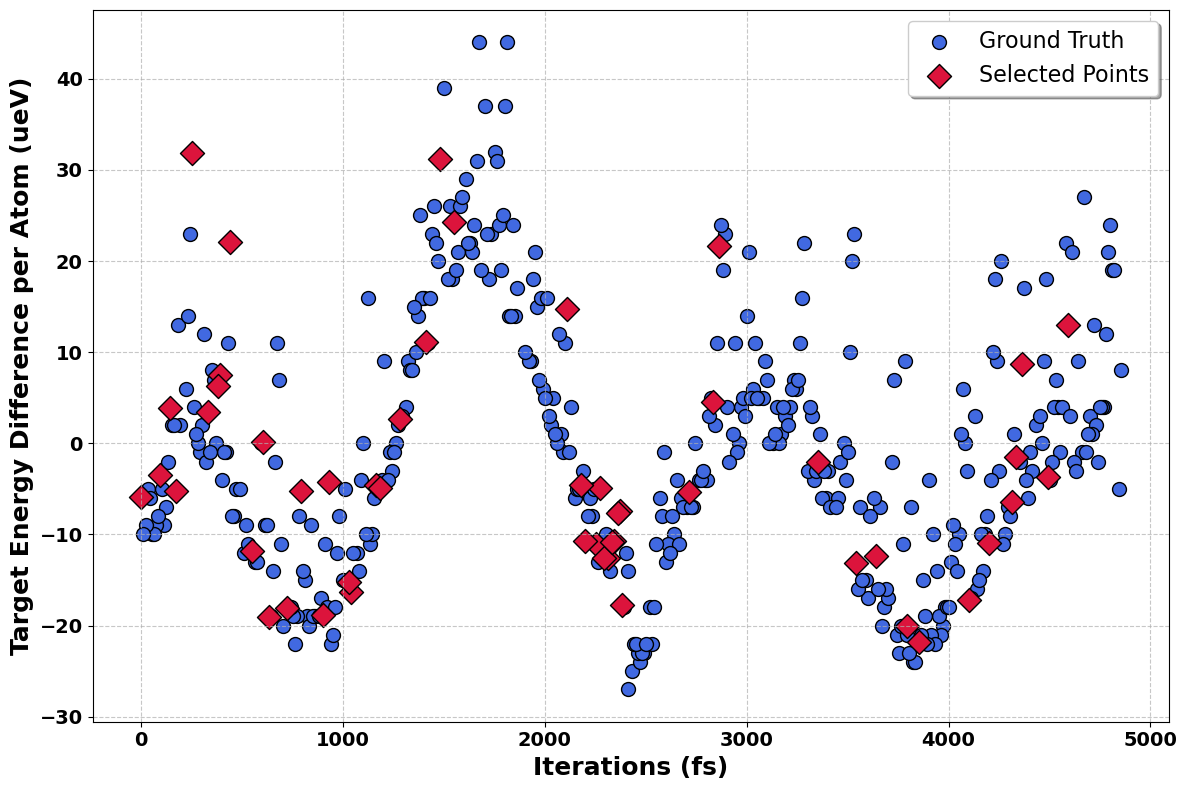

<Figure size 640x480 with 0 Axes>

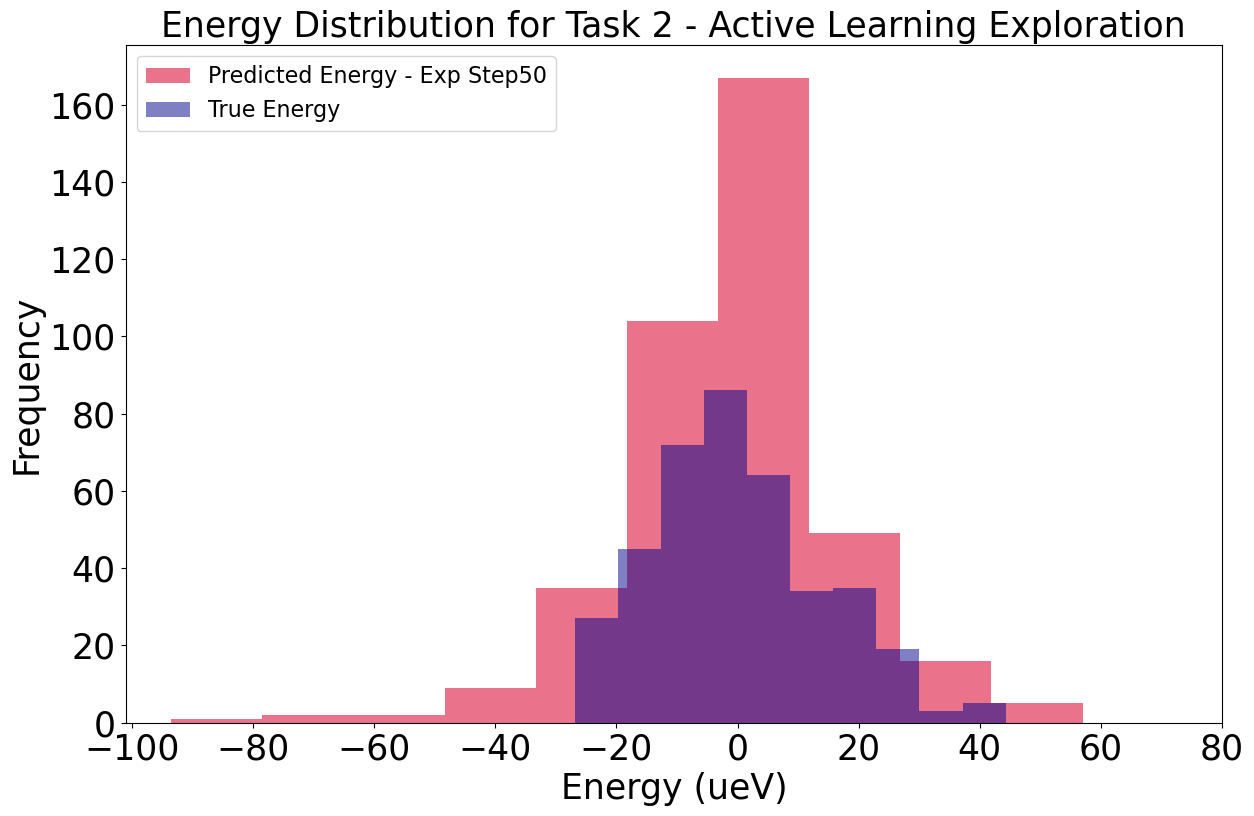

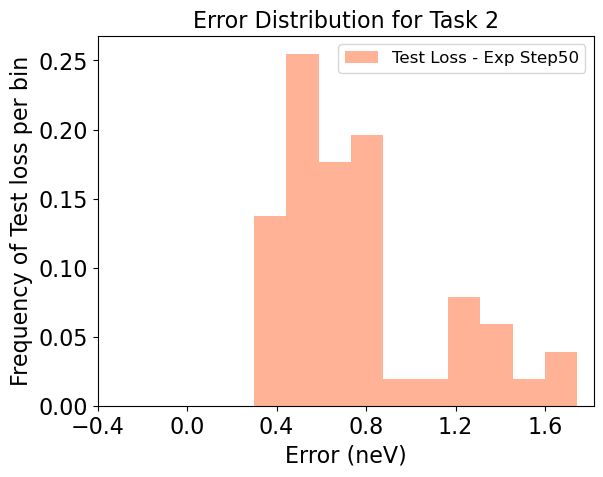

<Figure size 640x480 with 0 Axes>

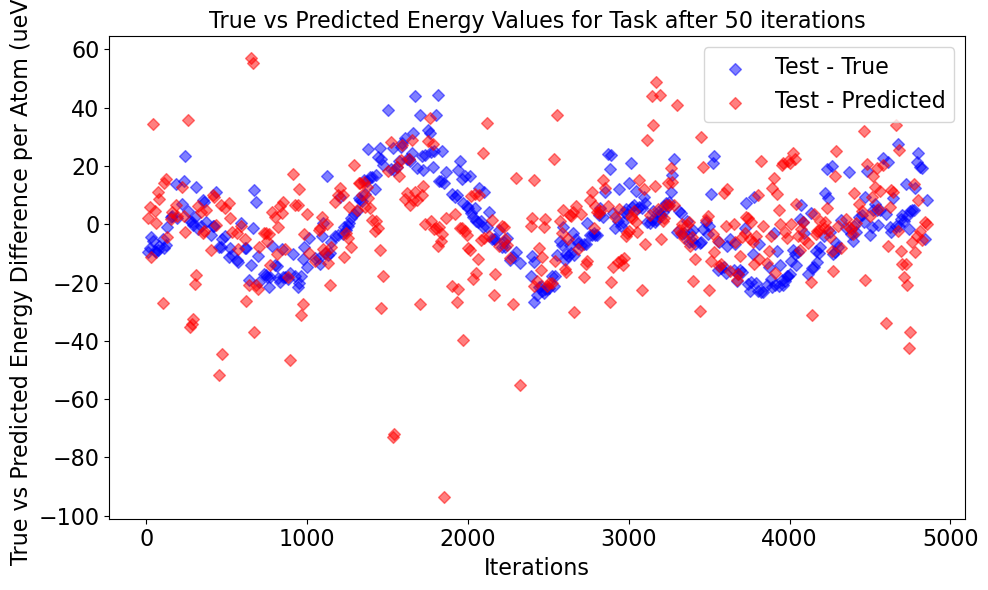

Iteration 52/151
Train MSE for task 1 : 4.010136043769771e-11
Test MSE for task 1 : 4.814061350814313e-10
Most uncertain indices : [1071.]
Iteration 53/151
Train MSE for task 1 : 6.001763235552743e-11
Test MSE for task 1 : 2.728026710029247e-10
Most uncertain indices : [1671.]
Iteration 54/151
Train MSE for task 1 : 6.321029073215193e-11
Test MSE for task 1 : 3.320876302071602e-10
Most uncertain indices : [2432.]
Iteration 55/151
Train MSE for task 1 : 4.57729120894768e-11
Test MSE for task 1 : 4.4225654571111683e-10
Most uncertain indices : [3092.]
Iteration 56/151
Train MSE for task 1 : 6.306521643757786e-11
Test MSE for task 1 : 3.6342173788072064e-10
Most uncertain indices : [671.]
Iteration 57/151
Train MSE for task 1 : 6.828019087598624e-11
Test MSE for task 1 : 3.4337689345679756e-10
Most uncertain indices : [2592.]
Iteration 58/151
Train MSE for task 1 : 5.6025214341475953e-11
Test MSE for task 1 : 4.967589077623419e-10
Most uncertain indices : [681.]
Iteration 59/151
Train MSE

<Figure size 640x480 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

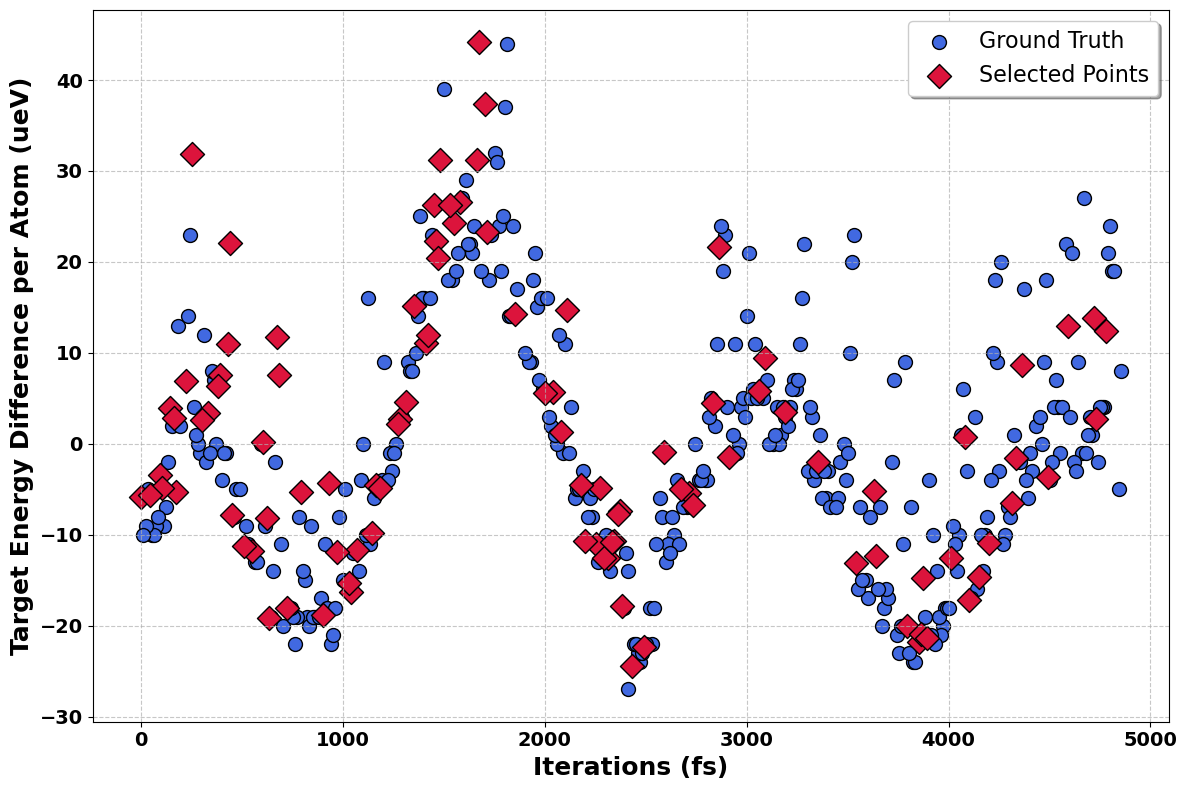

<Figure size 640x480 with 0 Axes>

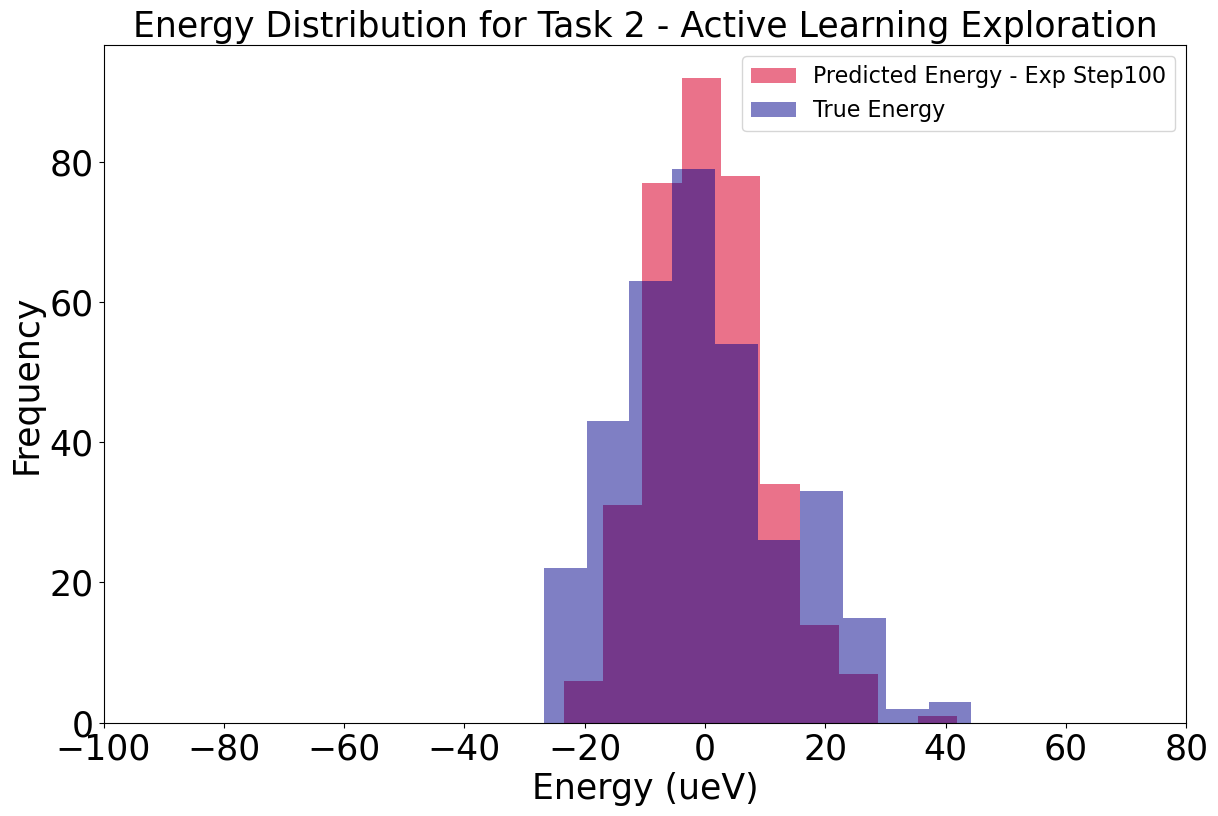

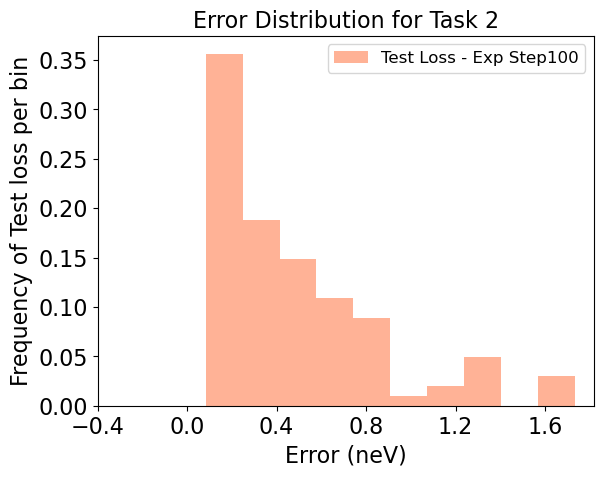

<Figure size 640x480 with 0 Axes>

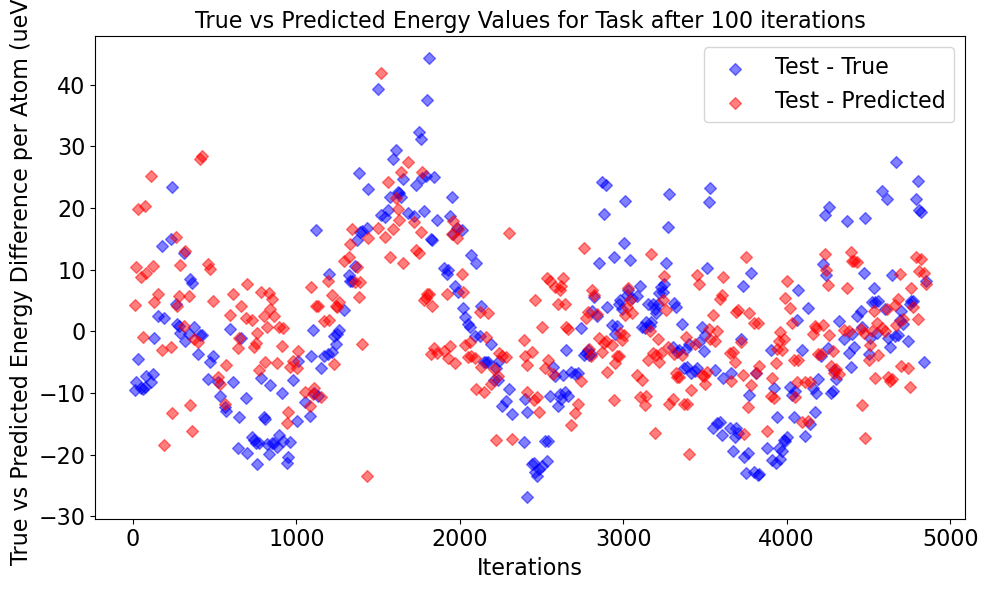

Iteration 102/151
Train MSE for task 1 : 9.098035937491933e-11
Test MSE for task 1 : 1.9689920745767725e-10
Most uncertain indices : [4412.]
Iteration 103/151
Train MSE for task 1 : 7.595580380440698e-11
Test MSE for task 1 : 2.0881764104310046e-10
Most uncertain indices : [2221.]
Iteration 104/151
Train MSE for task 1 : 9.882589070736195e-11
Test MSE for task 1 : 2.9138077651555946e-10
Most uncertain indices : [4402.]
Iteration 105/151
Train MSE for task 1 : 9.374468004185555e-11
Test MSE for task 1 : 1.6323193233101363e-10
Most uncertain indices : [401.]
Iteration 106/151
Train MSE for task 1 : 8.039935087957805e-11
Test MSE for task 1 : 1.871032884702002e-10
Most uncertain indices : [1371.]
Iteration 107/151
Train MSE for task 1 : 9.515170963301498e-11
Test MSE for task 1 : 1.6607417810625026e-10
Most uncertain indices : [891.]
Iteration 108/151
Train MSE for task 1 : 8.295801841083808e-11
Test MSE for task 1 : 2.1109597056715526e-10
Most uncertain indices : [841.]
Iteration 109/151

<Figure size 640x480 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

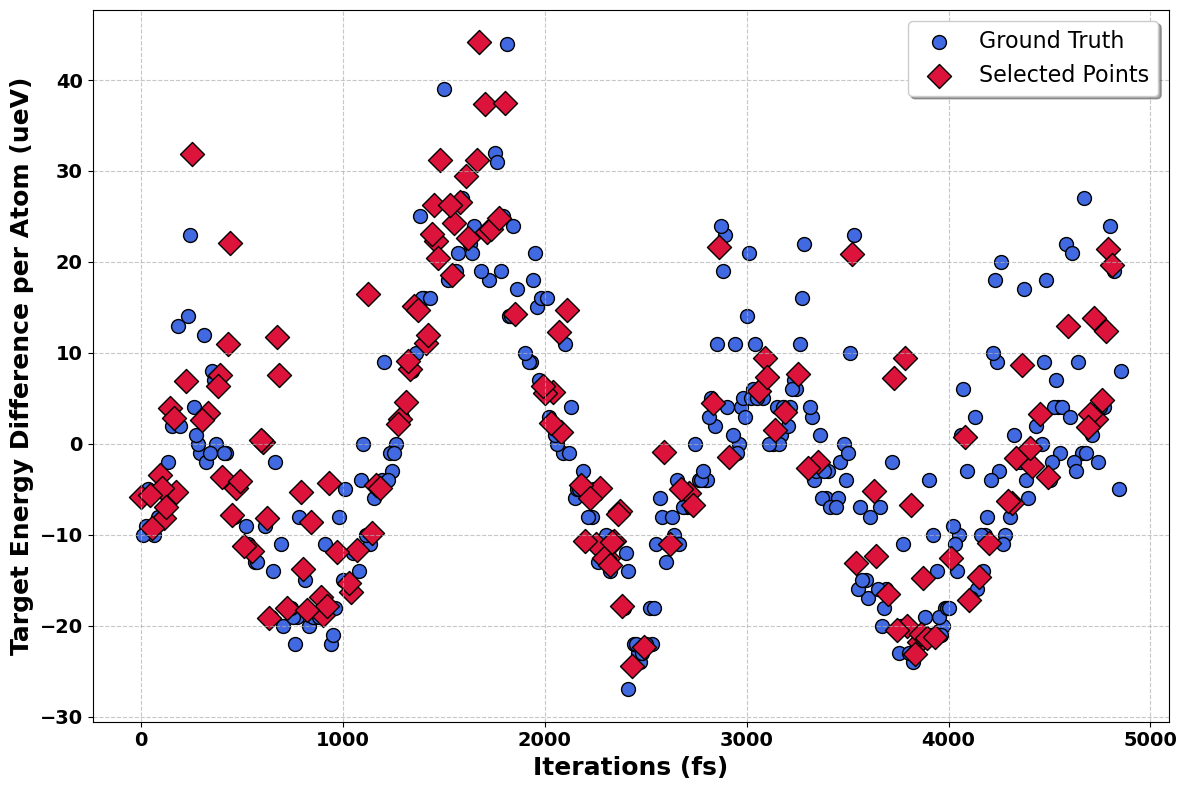

<Figure size 640x480 with 0 Axes>

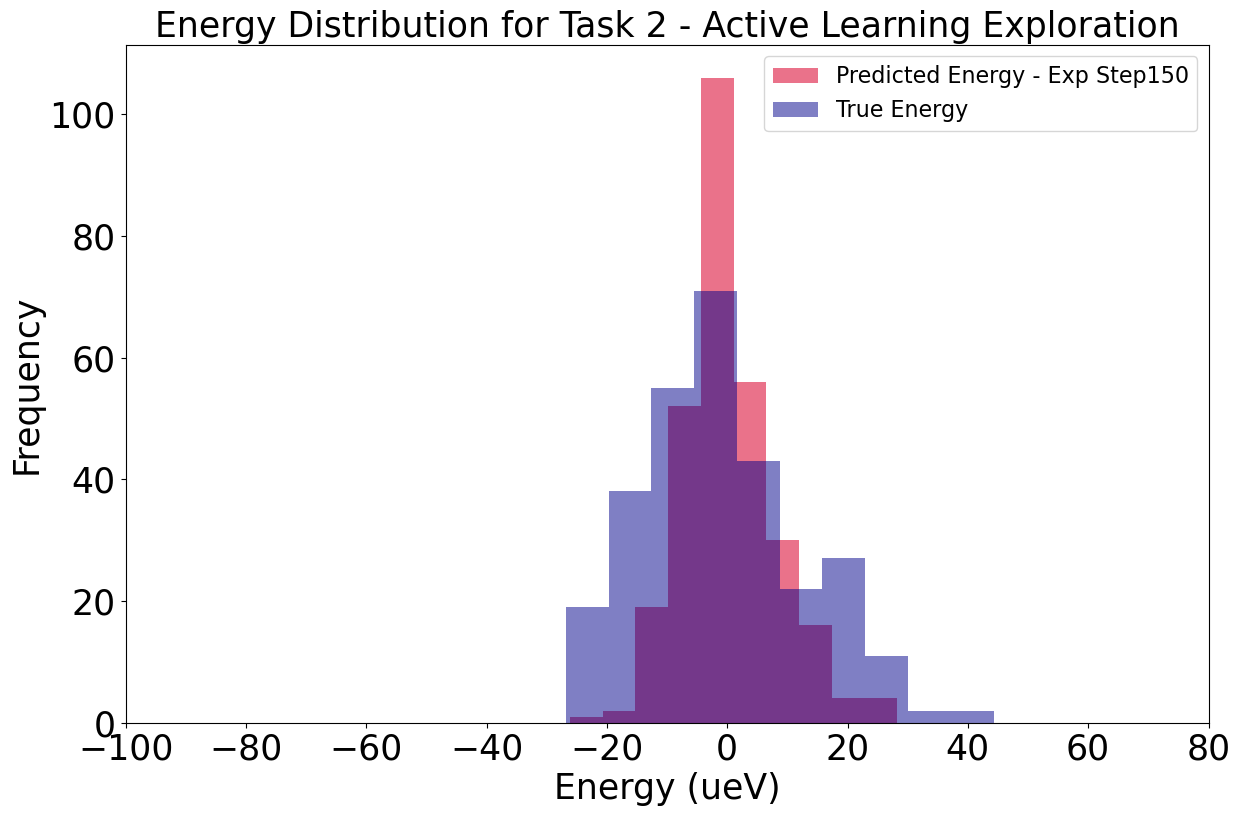

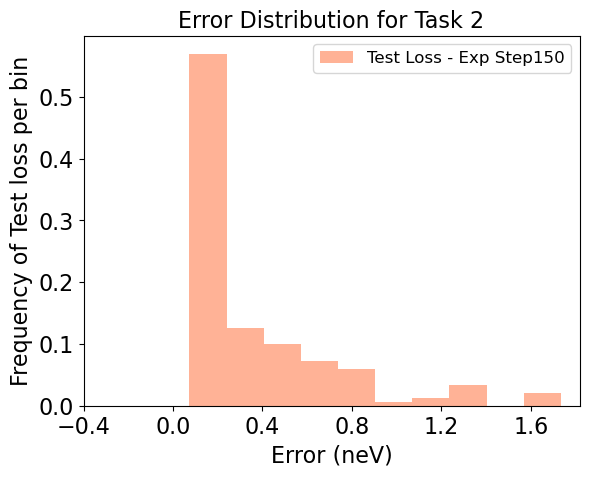

<Figure size 640x480 with 0 Axes>

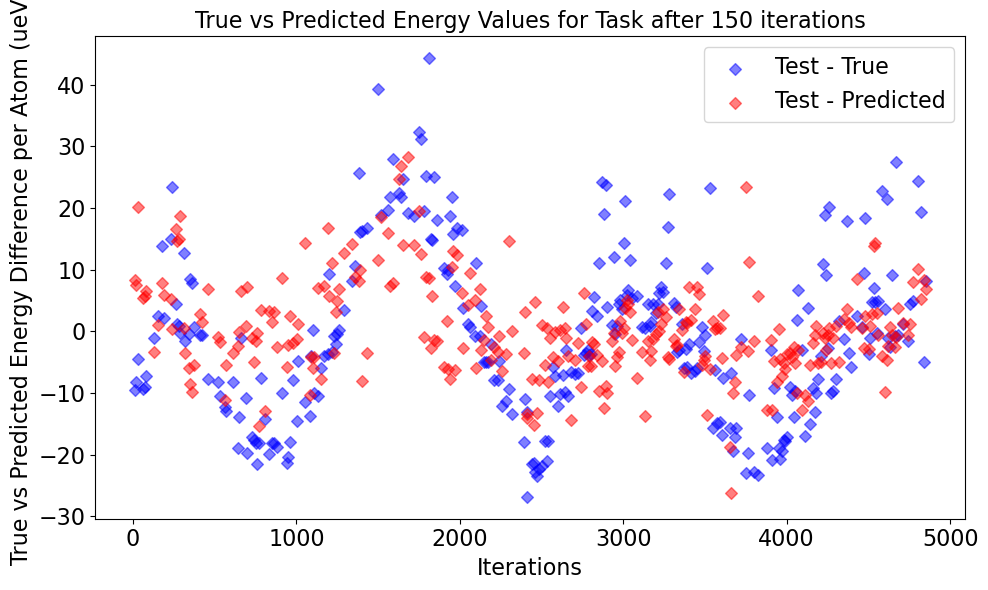

<Figure size 640x480 with 0 Axes>

In [23]:

def gmm_based_active_learning(task,image_mask,energy_to_ind,exploration_steps,acquisition, latent_features=None):
    if latent_features is None:
        latent_features = extract_latent_features(image_mask, task, energy_to_ind[task]["target_total_energy_per_atom"])
    iterations = energy_to_ind[task]["Iteration"]
    print("Latent Features Shape:", latent_features.shape)
    # Split dataset into training and testing
    np.random.seed(42)
    torch.manual_seed(42)
    energy_data = np.array(energy_to_ind[task]["target_total_energy_per_atom"]).reshape(-1,1)
    X_train, X_test, y_train, y_test, iterations_train, iterations_test = train_test_split(latent_features, energy_data, iterations, test_size=0.9, shuffle=True, random_state=42)

    num_iterations = exploration_steps
    num_samples_per_iteration = 1

    training_cycles = 30
    lr = 1e-2
    energy_index = energy_to_ind[task]['target_total_energy_per_atom'][iterations_test.index].index

    images = np.array(image_mask[task], dtype=np.float32)

    unlabeled_img = images[energy_index]

    train_x = torch.tensor(X_train, dtype = torch.float32)
    train_y = torch.tensor(np.array(y_train), dtype = torch.float32)
    test_x = torch.tensor(X_test, dtype = torch.float32)
    test_y = torch.tensor(np.array(y_test), dtype = torch.float32)

    target_labels = torch.tensor(np.array(energy_to_ind[task]['target_total_energy_per_atom'][iterations_test.index]),dtype=torch.float32)

    iterations_train = torch.tensor(np.array(iterations_train),dtype=torch.float32)
    iterations_test = torch.tensor(np.array(iterations_test),dtype=torch.float32)


    acquisiton_function = {
        "uncertainty": select_most_uncertain_samples,
        "stability" : select_most_stable_energy_samples,
    }

    selected_iter = []
    selected_energy = []
    training_loss = []
    test_loss = []
    
    model = GaussianMixture(n_components=selected_ncomp, covariance_type='full', random_state=42, reg_covar=1e-4)
    
    test_loss = []
    
    for iteration in range(num_iterations):
        
        print(f"Iteration {iteration+1}/{num_iterations}")
        XY = torch.hstack((train_x, train_y))
        start = time.time()
        model.fit(XY)
        end = time.time()
        # print("Time taken to fit the model:", end-start)
        # Obtain predictions from each tree in the forest
        Y_means = []
        Y_sigmas = []
        for i in range(train_x.shape[0]):
            x_query = train_x[i, :]  # single sample
            y_mean, y_sigma, _ = gmr_predict(model, np.array(x_query))
            Y_means.append(y_mean)
            Y_sigmas.append(y_sigma)
        Y_means = np.array(Y_means)
        Y_Sigmas = np.array(Y_sigmas)
        mse = mean_squared_error(train_y, Y_means)
        print("Train MSE for task", task, ":", mse)
        training_loss.append(mse)

        mu_y = []
        Sigma_y = []
        weights = []
        for i in range(test_x.shape[0]):
            x_query = test_x[i, :]  # single sample
            y_mean, y_sigma, weight = gmr_predict(model, np.array(x_query))
            mu_y.append(y_mean)
            Sigma_y.append(y_sigma)
        
        mu_y = np.array(mu_y)
        Sigma_y = np.array(Sigma_y)
        # fill na with mean
        mu_y = np.nan_to_num(mu_y)
        mse = mean_squared_error(test_y, mu_y)
        print("Test MSE for task", task, ":", mse)
        test_loss.append(mse)
        
        # Mean predictions across trees
        train_predictions = np.mean(Y_means, axis=0)
        test_predictions = np.mean(mu_y, axis=0)

        # Calculate variance (or standard deviation) across predictions
        train_prediction_variance = Y_Sigmas
        prediction_variance = Sigma_y.reshape(-1,)
        
        y_mean = train_predictions #best_model.predict(X_train)
        y_pred = test_predictions #best_model.predict(X_test)
        
        _, most_uncertain_index = torch.topk(torch.tensor(prediction_variance), 1)
        # most_uncertain_index = select_most_uncertain_samples(dklgp, test_x, num_samples=num_samples_per_iteration)
        # most_uncertain_index = acquisiton_function[acquisition](prediction_variance, num_samples=num_samples_per_iteration)
        print(f"Most uncertain indices : {iterations_test[most_uncertain_index.cpu().numpy()].cpu().numpy()}")
        unlabelled_images = [unlabeled_img[i] for i in most_uncertain_index]

        selected_iter.append(iterations_test[most_uncertain_index.cpu().numpy()].cpu().numpy())
        selected_energy.append(test_y[most_uncertain_index.cpu().numpy()].cpu().numpy())

        plot_images_by_indices(unlabelled_images, most_uncertain_index.cpu().numpy(), target_labels.cpu().numpy(), iterations_test.cpu().numpy(), task, iteration, acquisition, cols=num_samples_per_iteration)
        if iteration in [50, 100, 150]:
            print("Total time taken for active learning:", iteration*(end-start))
            # print("Prediction Variance:", max(prediction_variance))
            mod_plot_selected_points(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
            # mod_plot_selected_points_gif(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
            hist_test_y = np.array([val/1e-6 for val in test_y])
            hist_mu_y = np.array([val/1e-6 for val in mu_y])
            # #Plot Training Loss
            gmm_mod_plot_al_training_loss(test_loss,task,num_iterations,acquisition)
            plt.hist(hist_mu_y, bins=10, alpha=0.6, color='crimson', label=f'Predicted Energy - Exp Step{iteration}')
            plt.hist(hist_test_y, bins=10, alpha=0.5, label='True Energy', color='darkblue')
            plt.xticks([val for val in range(-100, 100, 20)], fontsize=25)
            plt.yticks(fontsize=25)
            plt.title(f'Energy Distribution for Task {task+1} - Active Learning Exploration', fontsize=25) 
            plt.xlabel('Energy (ueV)', fontsize=25)
            plt.ylabel('Frequency', fontsize=25)
            plt.legend(fontsize=16)
            plt.savefig(f"{cwd_path}/results/GMM/active_learning/energy_distribution_task{task+1}_exp_steps{iteration}.png")
            plt.show(block=True)
            plt.clf()
            # I want to plot the test loss distribution such that test loss per bin / total number of test samples
            # Compute the histogram bins and counts
            counts, bins = np.histogram(test_loss, bins=10)

            # Normalize the counts by the total number of test samples
            
            normalized_counts = counts / len(test_loss)
            bins = [val/1e-9 for val in bins]
            plt.bar(bins[:-1], normalized_counts, width=np.diff(bins), alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            # plt.hist(test_loss, bins=10, alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            plt.title(f'Error Distribution for Task {task+1}', fontsize= 16)
            plt.xticks(np.arange(-0.4, 2.0, 0.4),fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Error (neV)', fontsize=16)
            plt.ylabel('Frequency of Test loss per bin', fontsize=16)
            plt.legend(fontsize=12)
            plt.show(block=True)
            plt.clf()
            
            plt.figure(figsize=(10, 6))
            # plt.scatter(iterations_train, y_train, c='r', marker='*', alpha=0.5, label="Train - True")
            # plt.scatter(iterations_train, y_mean, c="b", marker='*', alpha=0.5, label="Train - Predicted")
            # plt.scatter(iterations_train, train_prediction_variance, color='green',  marker='*', alpha=0.5, label="Train Variance")
            plt.scatter(iterations_test, hist_test_y, c='b', marker='D', alpha=0.5, label="Test - True")
            plt.scatter(iterations_test, hist_mu_y, c="r", marker='D', alpha=0.5, label="Test - Predicted")
            # plt.scatter(iterations_test, prediction_variance, color='green', marker="D",alpha=0.5, label="Test Variance")
            plt.xlabel('Iterations', fontsize=16)
            plt.ylabel('True vs Predicted Energy Difference per Atom (ueV)', fontsize=16)
            plt.title("True vs Predicted Energy Values for Task after {} iterations".format(iteration), fontsize=16)
            plt.yticks(fontsize=16)
            plt.xticks(fontsize=16)
            plt.legend(fontsize=16)
            plt.tight_layout()
            plt.savefig(f"{cwd_path}/results/GMM/active_learning/regression_true_vs_predicted_task{task+1}_exp_steps{iteration}.png")
            plt.show(block=True)
            plt.clf()

        if iteration == num_iterations-1:
            break

        train_x = torch.cat((train_x, test_x[most_uncertain_index.item()][None]), 0)
        train_y = torch.cat((train_y, test_y[most_uncertain_index.item()].unsqueeze(0)), 0)

        test_x = torch.cat((test_x[:most_uncertain_index.item()], test_x[most_uncertain_index.item()+1:]), 0)
        test_y = torch.cat((test_y[:most_uncertain_index.item()], test_y[most_uncertain_index.item()+1:]), 0)
        
        
        unlabeled_img = torch.tensor(unlabeled_img)

        unlabeled_img = torch.cat((unlabeled_img[:most_uncertain_index.item()], unlabeled_img[most_uncertain_index.item()+1:]), 0)
        target_labels = torch.cat((target_labels[:most_uncertain_index.item()], target_labels[most_uncertain_index.item()+1:]), 0)
        
        iterations_test = torch.cat((iterations_test[:most_uncertain_index.item()], iterations_test[most_uncertain_index.item()+1:]), 0)
        
        
    return selected_energy, selected_iter, training_loss, test_loss, iterations_test,test_y, acquisition,task, num_iterations
selected_ncomp = 5
task = 1
for exp_step in [151]:
    selected_energy, selected_iter, gmm_training_loss, gmm_test_loss, iterations_test,test_y, acquisition,task, num_iterations = gmm_based_active_learning(task, cropped_image_list, energy_to_ind, exp_step, "uncertainty", latent_features)

## Tree Based Regressor

In [17]:
def training_tree_regressor(image_list, task, energy_to_ind, plot_regression=True):
    latent_features = extract_latent_features(image_list, task, energy_to_ind[task]["target_total_energy_per_atom"])
    energy_data = energy_to_ind[task]["target_total_energy_per_atom"]
    iterations = energy_to_ind[task]["Iteration"]
    # Split dataset into training and testing
    X_train, X_test, y_train, y_test, iterations_train, iterations_test = train_test_split(latent_features, energy_data, iterations, test_size=0.2, shuffle=True, random_state=42)

    # Build a Regression Pipeline with Scaling and Model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])

    # Hyperparameter Tuning
    param_grid = {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [None, 10, 20, 30],
        'regressor__min_samples_split': [2, 5, 10]
    }

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2)
    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()
    print(f"Training Time: {end - start} seconds")
    prediction = grid_search.predict(X_test)

    # Evaluate Model
    best_model = grid_search.best_estimator_

    # Variance Calculation with Random Forest

    random_forest = RandomForestRegressor(
        n_estimators=grid_search.best_params_['regressor__n_estimators'],
        max_depth=grid_search.best_params_['regressor__max_depth'],
        min_samples_split=grid_search.best_params_['regressor__min_samples_split'],
        random_state=42,
        bootstrap=True
    )

    random_forest.fit(X_train, y_train)
    
    # Obtain predictions from each tree in the forest
    all_train_predictions = np.array([tree.predict(X_train) for tree in random_forest.estimators_])
    all_tree_predictions = np.array([tree.predict(X_test) for tree in random_forest.estimators_])

    # Mean predictions across trees
    train_predictions = np.mean(all_train_predictions, axis=0)
    test_predictions = np.mean(all_tree_predictions, axis=0)

    # Calculate variance (or standard deviation) across predictions
    train_prediction_variance = np.var(all_train_predictions, axis=0)
    prediction_variance = np.var(all_tree_predictions, axis=0)
    prediction_std_dev = np.sqrt(prediction_variance)

    print("Best Model:", best_model)
    y_mean = train_predictions #best_model.predict(X_train)
    y_pred = test_predictions #best_model.predict(X_test)

    # Calculate Evaluation Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Mean Squared Error: {mse}')
    print(f'R2 Score: {r2}')
    if plot_regression == True:
        # Optional: Plotting Predicted vs True Values
        plt.scatter(iterations_train,y_train, c='b', marker='*', alpha=0.5, label="Train - True")
        plt.scatter(iterations_train, y_mean, c="r", marker='*', alpha=0.5, label="Train - Predicted")
        plt.scatter(iterations_test,y_test, c='b', marker='D', alpha=0.5, label="Test - True")
        plt.scatter(iterations_test, y_pred, c="r", marker='D', alpha=0.5, label="Test - Predicted")
        plt.xlabel('Values')
        plt.ylabel('True vs Predicted Values')
        plt.title('True vs Predicted Energy Values for Task ' + str(task))
        plt.legend()
        if not os.path.exists(f"{cwd_path}/results/tree_regressor/"):
            os.makedirs(f"{cwd_path}/results/tree_regressor/")
        plt.savefig(f"{cwd_path}/results/tree_regressor/true_vs_predicted_task{task}.png")
        plt.clf()
    return grid_search, train_predictions, test_predictions, train_prediction_variance, prediction_variance


In [18]:
grid_search, train_predictions, test_predictions, train_prediction_variance, prediction_variance = training_tree_regressor(cropped_image_list, task, energy_to_ind, plot_regression=True)

KeyboardInterrupt: 

Latent Features Shape: (488, 32)
Iteration 1/151
Mean Squared Error of Iteration 1: 2.1976334620251556e-10
Iteration 2/151
Mean Squared Error of Iteration 2: 2.179192524663973e-10
Iteration 3/151
Mean Squared Error of Iteration 3: 2.1935662840392297e-10
Iteration 4/151
Mean Squared Error of Iteration 4: 2.2418376830288162e-10
Iteration 5/151
Mean Squared Error of Iteration 5: 2.2288179282312808e-10
Iteration 6/151
Mean Squared Error of Iteration 6: 2.1715618034477645e-10
Iteration 7/151
Mean Squared Error of Iteration 7: 2.1912674642483716e-10
Iteration 8/151
Mean Squared Error of Iteration 8: 2.2465355488582985e-10
Iteration 9/151
Mean Squared Error of Iteration 9: 2.180754071444298e-10
Iteration 10/151
Mean Squared Error of Iteration 10: 2.2099539093495126e-10
Iteration 11/151
Mean Squared Error of Iteration 11: 2.2283549615458795e-10
Iteration 12/151
Mean Squared Error of Iteration 12: 2.2398656780120816e-10
Iteration 13/151
Mean Squared Error of Iteration 13: 2.2689824872139102e-10

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

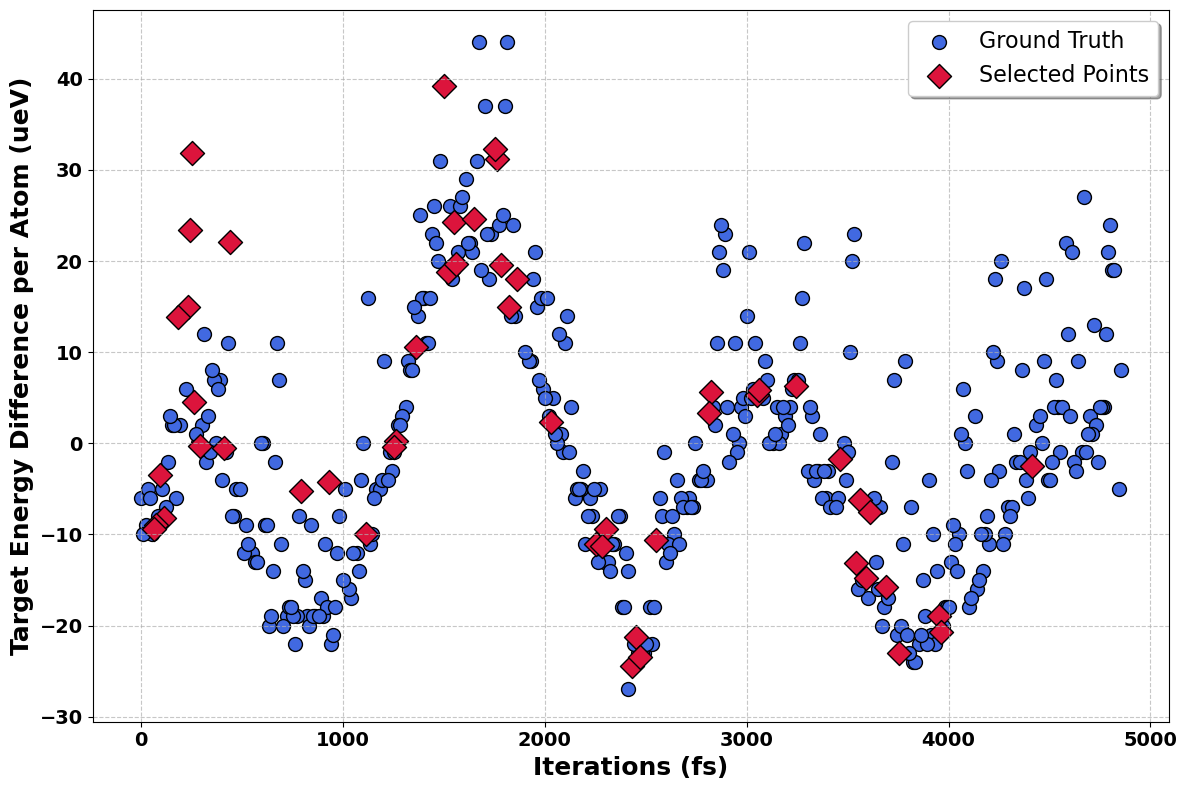

<Figure size 640x480 with 0 Axes>

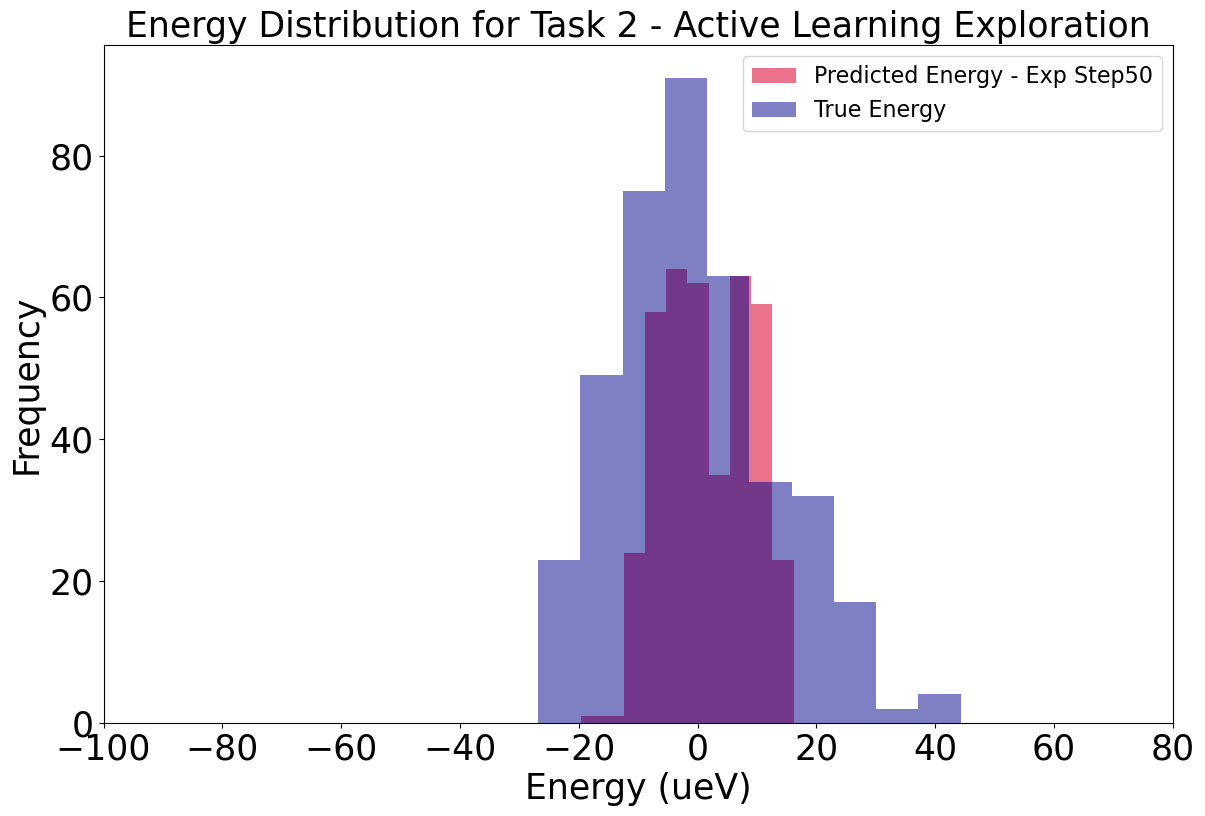

Normalized Counts: [0.03921569 0.09803922 0.09803922 0.11764706 0.17647059 0.21568627
 0.03921569 0.05882353 0.09803922 0.05882353]


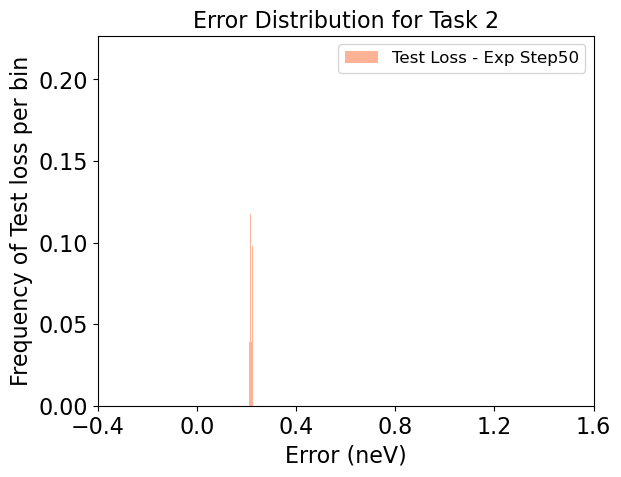

torch.Size([390]) (390, 1) (390,)


<Figure size 640x480 with 0 Axes>

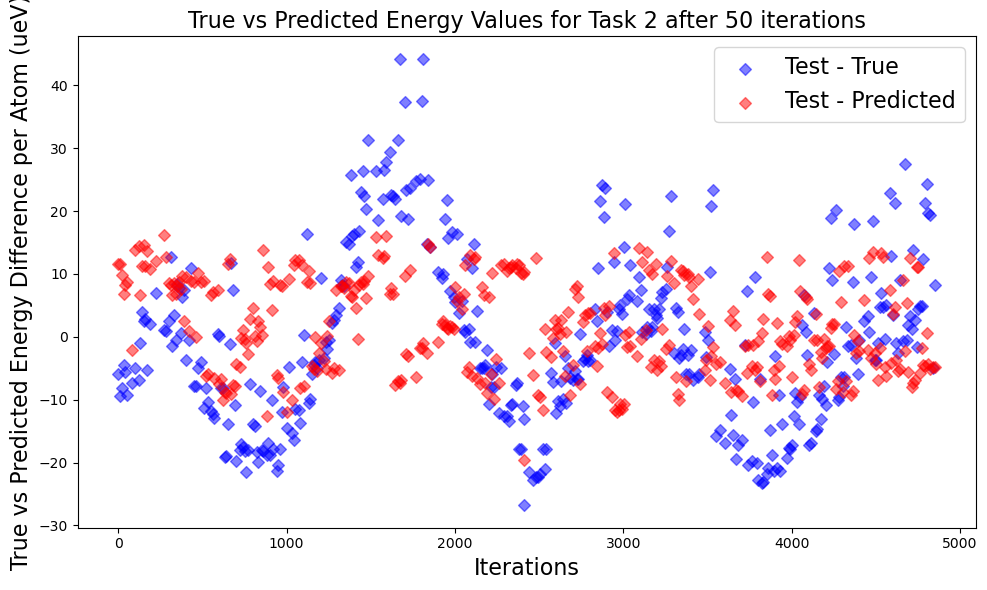

Iteration 52/151
Mean Squared Error of Iteration 52: 2.1081801032234433e-10
Iteration 53/151
Mean Squared Error of Iteration 53: 2.0949881816914665e-10
Iteration 54/151
Mean Squared Error of Iteration 54: 2.1413000303208065e-10
Iteration 55/151
Mean Squared Error of Iteration 55: 2.1028633942852525e-10
Iteration 56/151
Mean Squared Error of Iteration 56: 2.13520907470671e-10
Iteration 57/151
Mean Squared Error of Iteration 57: 2.1073748894042429e-10
Iteration 58/151
Mean Squared Error of Iteration 58: 2.122654894532497e-10
Iteration 59/151
Mean Squared Error of Iteration 59: 2.1006462817101474e-10
Iteration 60/151
Mean Squared Error of Iteration 60: 2.1153856277336702e-10
Iteration 61/151
Mean Squared Error of Iteration 61: 2.1483761222148205e-10
Iteration 62/151
Mean Squared Error of Iteration 62: 2.1339127131908995e-10
Iteration 63/151
Mean Squared Error of Iteration 63: 2.151748413967659e-10
Iteration 64/151
Mean Squared Error of Iteration 64: 2.1394800694678446e-10
Iteration 65/151

Iteration 93/151
Mean Squared Error of Iteration 93: 2.2026719115948008e-10
Iteration 94/151
Mean Squared Error of Iteration 94: 2.114579174990023e-10
Iteration 95/151
Mean Squared Error of Iteration 95: 2.1211371206345923e-10
Iteration 96/151
Mean Squared Error of Iteration 96: 2.058452812778016e-10
Iteration 97/151
Mean Squared Error of Iteration 97: 2.0499057286166203e-10
Iteration 98/151
Mean Squared Error of Iteration 98: 2.040009711832225e-10
Iteration 99/151
Mean Squared Error of Iteration 99: 2.0229798220420143e-10
Iteration 100/151
Mean Squared Error of Iteration 100: 2.0609522460803705e-10
Iteration 101/151
Mean Squared Error of Iteration 101: 2.0200640663920184e-10
Total time taken for active learning: 0.49591064453125
Variance of Predictions: [6.02146074e-11 6.71185936e-11 8.41667349e-11 1.26864597e-10
 9.08740545e-11 7.95864478e-11 6.81258880e-11 6.98541133e-11
 7.75432362e-11 1.34736757e-11 8.48444555e-11 1.04622693e-10
 1.55354038e-10 6.58785032e-11 6.62583317e-11 8.2771

<Figure size 640x480 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

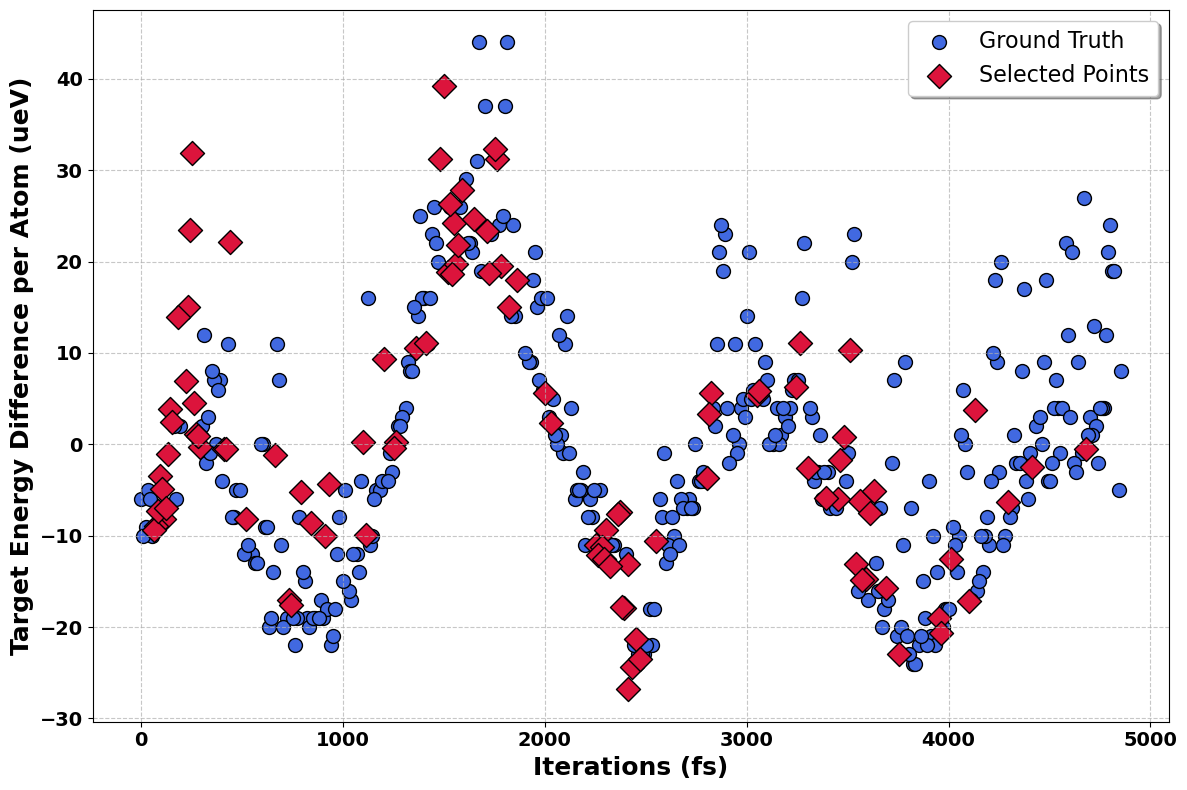

<Figure size 640x480 with 0 Axes>

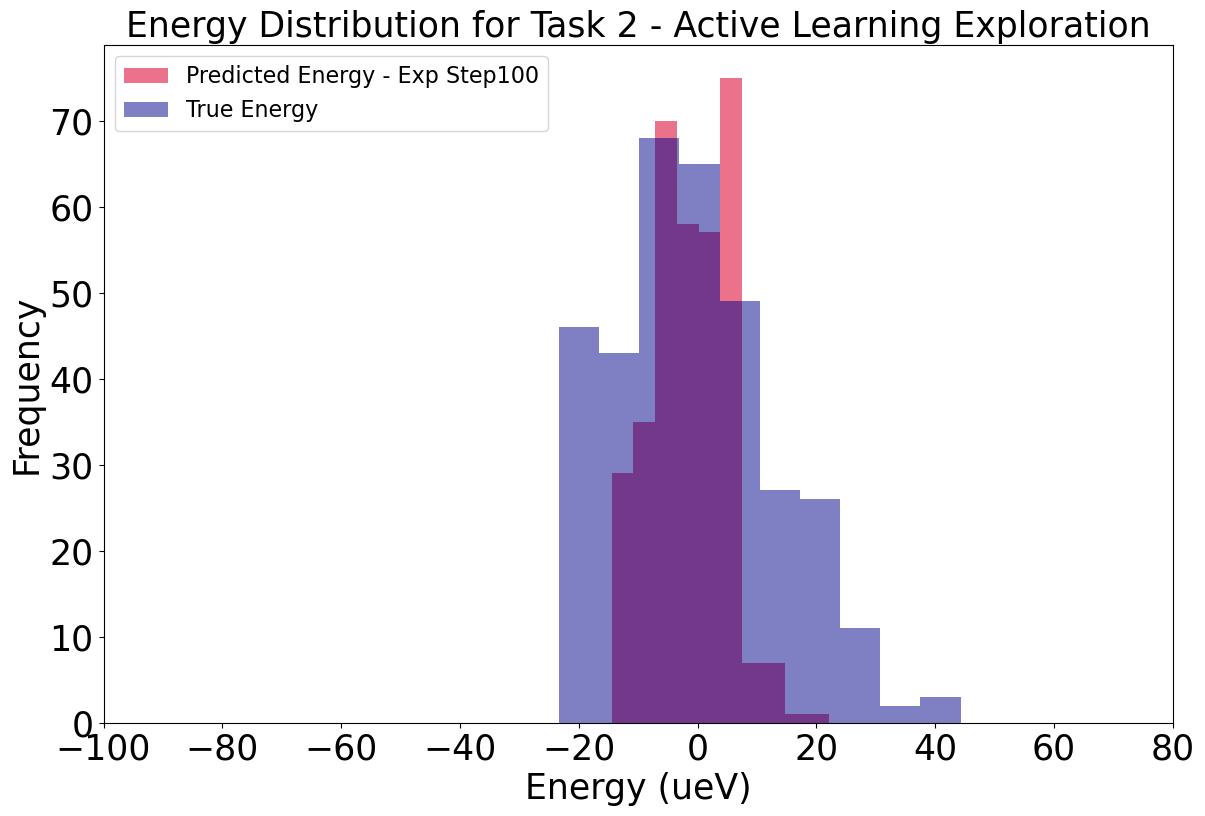

Normalized Counts: [0.02970297 0.02970297 0.04950495 0.10891089 0.21782178 0.18811881
 0.18811881 0.11881188 0.03960396 0.02970297]


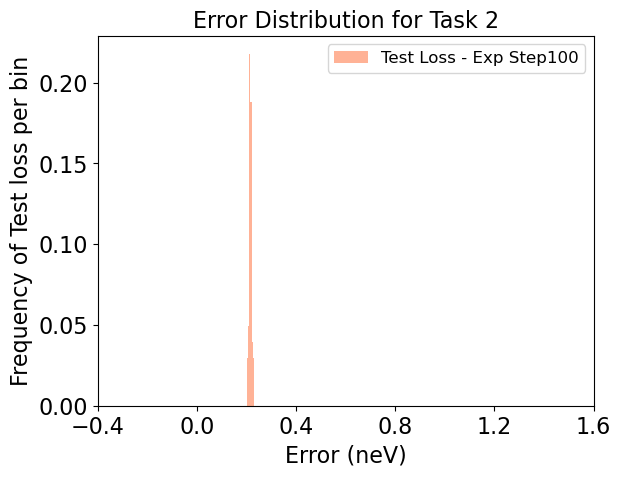

torch.Size([340]) (340, 1) (340,)


<Figure size 640x480 with 0 Axes>

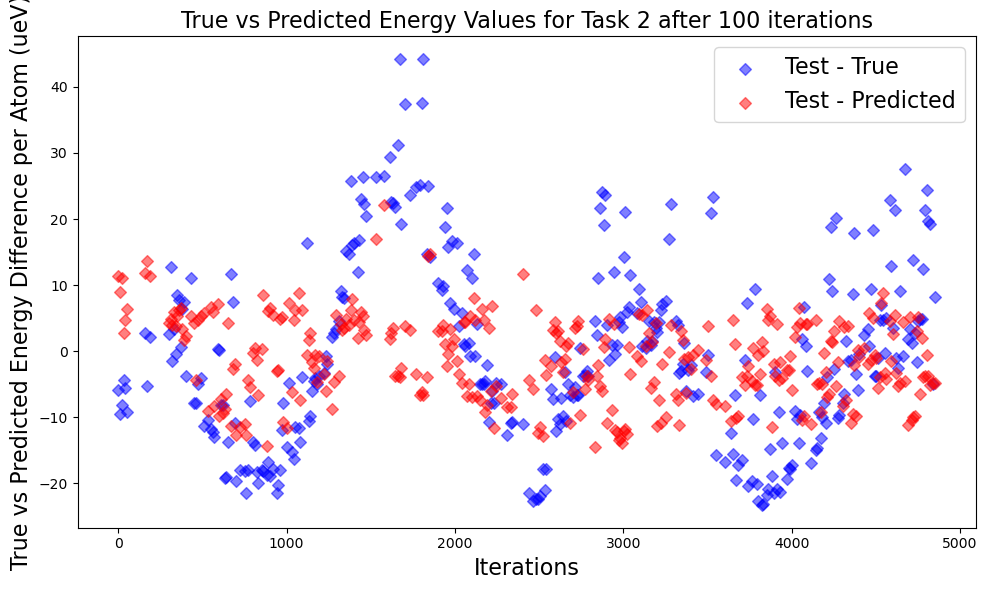

Iteration 102/151
Mean Squared Error of Iteration 102: 2.0470056634455397e-10
Iteration 103/151
Mean Squared Error of Iteration 103: 1.995749323458979e-10
Iteration 104/151
Mean Squared Error of Iteration 104: 2.0517020211406299e-10
Iteration 105/151
Mean Squared Error of Iteration 105: 2.0285310292827007e-10
Iteration 106/151
Mean Squared Error of Iteration 106: 2.0571016675191088e-10
Iteration 107/151
Mean Squared Error of Iteration 107: 2.0667538114815616e-10
Iteration 108/151
Mean Squared Error of Iteration 108: 2.0823487378777663e-10
Iteration 109/151
Mean Squared Error of Iteration 109: 2.0714157497792258e-10
Iteration 110/151
Mean Squared Error of Iteration 110: 2.0658903665458314e-10
Iteration 111/151
Mean Squared Error of Iteration 111: 2.0607349999822257e-10
Iteration 112/151
Mean Squared Error of Iteration 112: 2.0414712338599826e-10
Iteration 113/151
Mean Squared Error of Iteration 113: 2.0391447664570646e-10
Iteration 114/151
Mean Squared Error of Iteration 114: 2.05743424

<Figure size 640x480 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

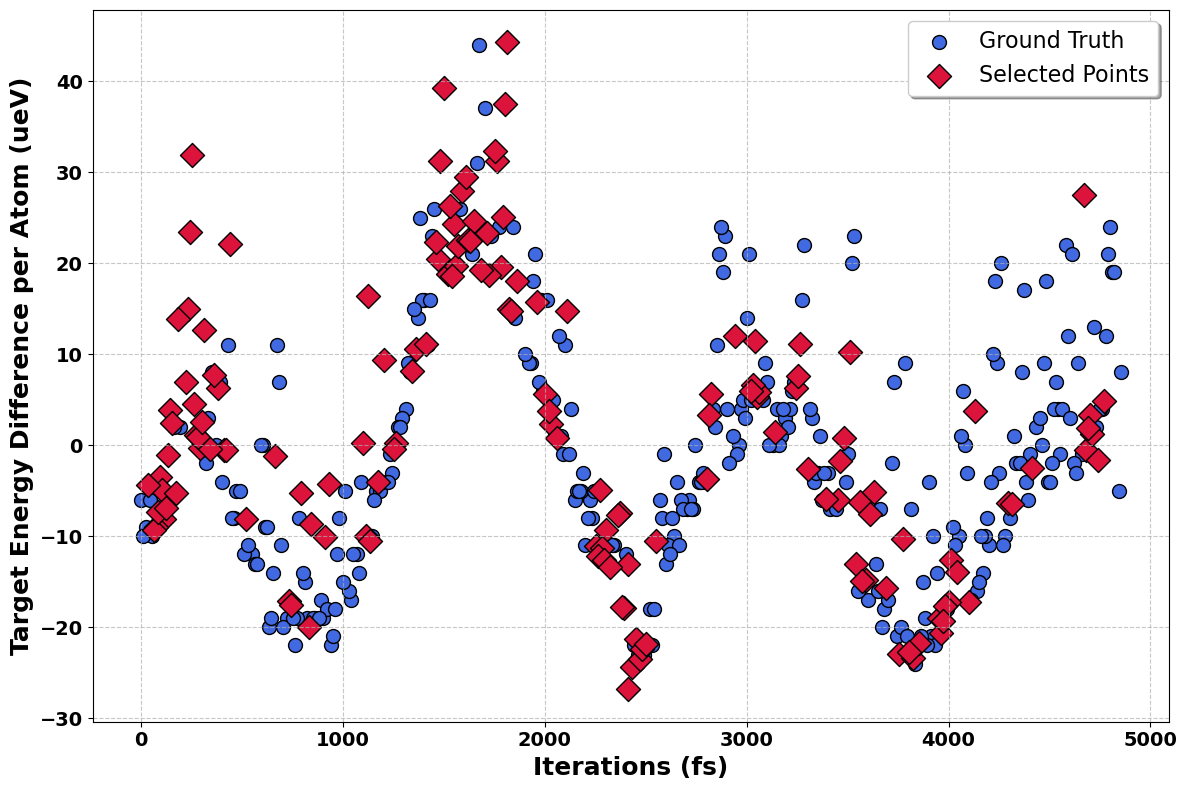

<Figure size 640x480 with 0 Axes>

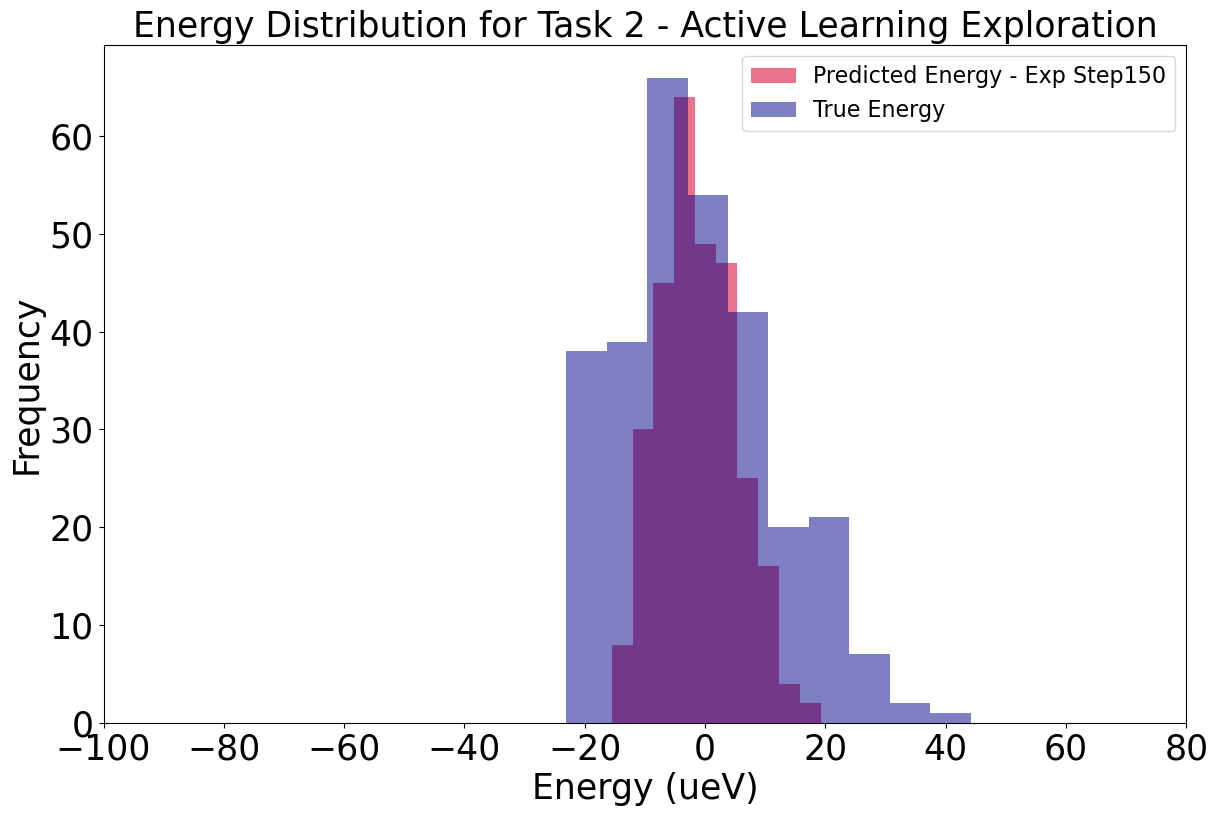

Normalized Counts: [0.07284768 0.01324503 0.01986755 0.         0.03311258 0.09933775
 0.1192053  0.22516556 0.31125828 0.10596026]


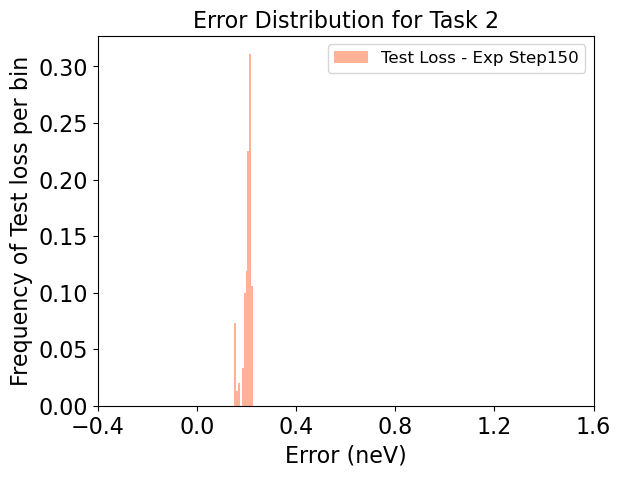

torch.Size([290]) (290, 1) (290,)


<Figure size 640x480 with 0 Axes>

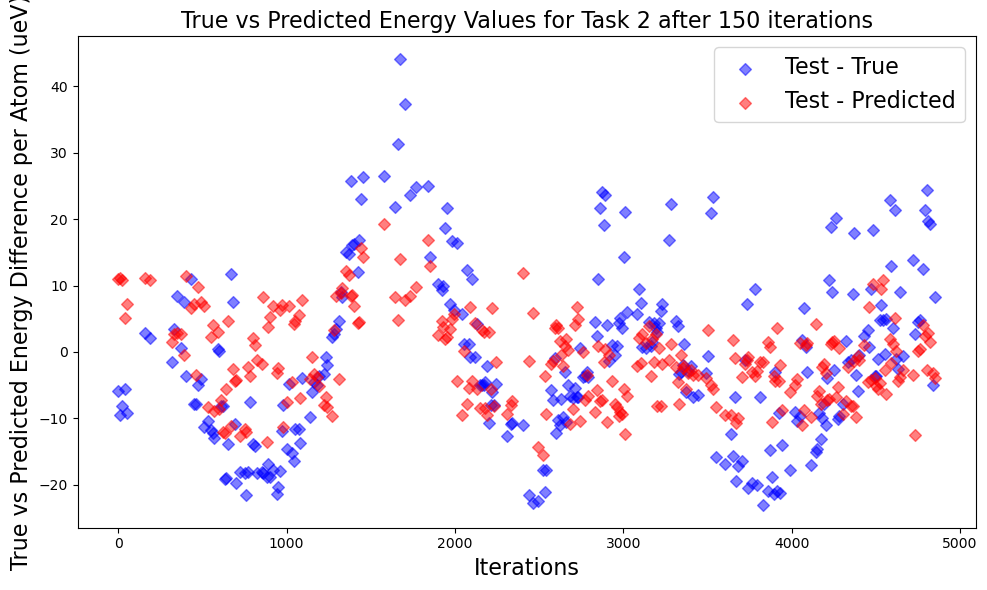

<Figure size 640x480 with 0 Axes>

In [24]:
from ensembling_for_AIMD import plot_images_by_indices as plot_images_by_indices_tree
import joblib

def tree_based_active_learning(grid_search, task,image_mask,energy_to_ind,exploration_steps,acquisition, latent_features=None):
    if latent_features is None:
        latent_features = extract_latent_features(image_mask, task, energy_to_ind[task]["target_total_energy_per_atom"])
    iterations = energy_to_ind[task]["Iteration"]
    print("Latent Features Shape:", latent_features.shape)
    # Split dataset into training and testing
    np.random.seed(42)
    torch.manual_seed(42)
    energy_data = np.array(energy_to_ind[task]["target_total_energy_per_atom"]).reshape(-1,1)
    X_train, X_test, y_train, y_test, iterations_train, iterations_test = train_test_split(latent_features, energy_data, iterations, test_size=0.9, shuffle=True, random_state=42)

    num_iterations = exploration_steps
    num_samples_per_iteration = 1

    training_cycles = 20
    lr = 1e-1
    energy_index = energy_to_ind[task]['target_total_energy_per_atom'][iterations_test.index].index
    
    images = np.array(image_mask[task], dtype=np.float32)
    
    unlabeled_img = images[energy_index]
    # X_train = np.squeeze(X_train,axis=1)
    # X_test = np.squeeze(X_test,axis=1)

    # s1,s2,s3 = X_train.shape
    # X_train = X_train.reshape(-1,s2*s3)
    # X_test = X_test.reshape(-1,s2*s3)

    # y_train = np.array(y_train).reshape(1,-1)
    # y_test = np.array(y_test).reshape(1,-1)

    # true_labels = energy_to_ind[task]['target_total_energy_per_atom'] 
    # print(f"Training data shape: {X_train.shape}, {y_train.shape}")
    train_x = torch.tensor(X_train, dtype = torch.float32)
    train_y = torch.tensor(np.array(y_train), dtype = torch.float32)
    test_x = torch.tensor(X_test, dtype = torch.float32)
    test_y = torch.tensor(np.array(y_test), dtype = torch.float32)

    target_labels = torch.tensor(np.array(energy_to_ind[task]['target_total_energy_per_atom'][iterations_test.index]),dtype=torch.float32)

    iterations_train = torch.tensor(np.array(iterations_train),dtype=torch.float32)
    iterations_test = torch.tensor(np.array(iterations_test),dtype=torch.float32)


    acquisiton_function = {
        "uncertainty": select_most_uncertain_samples,
        "stability" : select_most_stable_energy_samples,
    }

    selected_iter = []
    selected_energy = []
    training_loss = []
    test_loss = []
    # model_mod = torch.nn.Sequential(
    #                                 torch.nn.Linear(datadim,2048),
    #                                 torch.nn.ReLU(),
    #                                 # torch.nn.Linear(10240,2048),
    #                                 # torch.nn.ReLU(),
    #                                 torch.nn.Linear(2048,1024),
    #                                 torch.nn.ReLU(),
    #                                 torch.nn.Linear(1024, 256),
    #                                 torch.nn.ReLU(),
    #                                 *(list(fcFeatureExtractor(256,embedim).children())),)

    # dklgp = dklgpreg.dklGPR(datadim,embedim,hidden_dim=[1000,500,50],feature_extract=copy.deepcopy(model_mod),precision="single")#aoi.models.dklGPR(data_dim, embedim=2, precision="double")
    model = RandomForestRegressor(
        n_estimators=grid_search.best_params_['regressor__n_estimators'],
        max_depth=grid_search.best_params_['regressor__max_depth'],
        min_samples_split=grid_search.best_params_['regressor__min_samples_split'],
        random_state=42,
        bootstrap=True
    )
    for iteration in range(num_iterations):
        
        print(f"Iteration {iteration+1}/{num_iterations}")
        
        model.fit(train_x, train_y)
        # Obtain predictions from each tree in the forest
        start = time.time()
        all_train_predictions = np.array([tree.predict(train_x) for tree in model.estimators_])
        end = time.time()

        all_tree_predictions = np.array([tree.predict(test_x) for tree in model.estimators_])

        # Mean predictions across trees
        train_predictions = np.mean(all_train_predictions, axis=0)
        test_predictions = np.mean(all_tree_predictions, axis=0)

        
        # Calculate variance (or standard deviation) across predictions
        train_prediction_variance = np.var(all_train_predictions, axis=0)
        prediction_variance = np.var(all_tree_predictions, axis=0)
        
        y_mean = train_predictions #best_model.predict(X_train)
        y_pred = test_predictions #best_model.predict(X_test)
        mse = mean_squared_error(train_y, y_mean)
        training_loss.append(mse)
        mse = mean_squared_error(test_y, y_pred)
        print(f'Mean Squared Error of Iteration {iteration+1}: {mse}')
        test_loss.append(mse)

        # most_uncertain_index = select_most_uncertain_samples(dklgp, test_x, num_samples=num_samples_per_iteration)
        most_uncertain_index = acquisiton_function[acquisition](prediction_variance, num_samples=num_samples_per_iteration)
        # print(f"Most uncertain indices: {most_uncertain_index}")

        unlabelled_images = [unlabeled_img[i] for i in most_uncertain_index]

        selected_iter.append(iterations_test[most_uncertain_index.cpu().numpy()].cpu().numpy())
        selected_energy.append(test_y[most_uncertain_index.cpu().numpy()].cpu().numpy())

        plot_images_by_indices_tree(unlabelled_images, most_uncertain_index.cpu().numpy(), target_labels.cpu().numpy(), iterations_test.cpu().numpy(), task, iteration, acquisition, cols=num_samples_per_iteration)
        
        if iteration in [50, 100, 150]:
            print("Total time taken for active learning:", iteration*(end-start))
            print("Variance of Predictions:", prediction_variance)
            mod_plot_selected_points(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
            # mod_plot_selected_points_gif(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
            hist_test_y = np.array([val/1e-6 for val in test_y])
            hist_mu_y = np.array([val/1e-6 for val in y_pred])
            # #Plot Training Loss
            tree_mod_plot_al_training_loss(test_loss,task,num_iterations,acquisition)
            plt.hist(hist_mu_y, bins=10, alpha=0.6, color='crimson', label=f'Predicted Energy - Exp Step{iteration}')
            plt.hist(hist_test_y, bins=10, alpha=0.5, label='True Energy', color='darkblue')
            plt.xticks([val for val in range(-100, 100, 20)], fontsize=25)
            plt.yticks(fontsize=25)
            plt.title(f'Energy Distribution for Task {task+1} - Active Learning Exploration', fontsize=25) 
            plt.xlabel('Energy (ueV)', fontsize=25)
            plt.ylabel('Frequency', fontsize=25)
            plt.legend(fontsize=16)
            plt.savefig(f"{cwd_path}/results/tree_regressor/active_learning/energy_distribution_task{task+1}_exp_steps{iteration}.png")
            plt.show(block=True)
            plt.clf()

            counts, bins = np.histogram(test_loss, bins=10)

            # Normalize the counts by the total number of test samples
            
            normalized_counts = counts / len(test_loss)
            print("Normalized Counts:", normalized_counts)
            bins = [val/1e-9 for val in bins]
            plt.bar(bins[:-1], normalized_counts, width=np.diff(bins), alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            # plt.hist(test_loss, bins=10, alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            plt.title(f'Error Distribution for Task {task+1}', fontsize= 16)
            plt.xticks(np.arange(-0.4, 2.0, 0.4),fontsize=16)
            
            # plt.bar(bins[:-1], normalized_counts, width=np.diff(bins), alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            # # plt.hist(test_loss, bins=10, alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            # plt.title(f'Error Distribution for Task {task+1}', fontsize= 16)
            # plt.xticks(np.arange(0.0e-9, 0.4e-9, 0.1e-9),fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Error (neV)', fontsize=16)
            plt.ylabel('Frequency of Test loss per bin', fontsize=16)
            plt.legend(fontsize=12)
            plt.show(block=True)
            plt.clf()
                        
            # plt.hist(test_loss, bins=10, alpha=0.6, color='coral', label=f'Test Loss - Exp Step{iteration}')
            # plt.title(f'Test Loss Distribution for Task {task+1} - Active Learning Exploration', fontsize=16)
            # plt.xticks(np.arange(-1.4e-9, 1.8e-9, 0.4e-9),fontsize=16)
            # plt.yticks(fontsize=16)
            # plt.xlabel('Loss', fontsize=16)
            # plt.ylabel('Frequency', fontsize=16)
            # plt.legend(fontsize=16)
            # plt.show(block=True)
            # plt.clf()
            

            plt.figure(figsize=(10, 6))
            # plt.scatter(iterations_train, y_train, c='r', marker='*', alpha=0.5, label="Train - True")
            # plt.scatter(iterations_train, y_mean, c="b", marker='*', alpha=0.5, label="Train - Predicted")
            # plt.scatter(iterations_train, train_prediction_variance, color='green',  marker='*', alpha=0.5, label="Train Variance")
            print(iterations_test.shape, hist_test_y.shape, hist_mu_y.shape)
            plt.scatter(iterations_test, hist_test_y, c='b', marker='D', alpha=0.5, label="Test - True")
            plt.scatter(iterations_test, hist_mu_y, c="r", marker='D', alpha=0.5, label="Test - Predicted")
            # plt.scatter(iterations_test, prediction_variance, color='green', marker="D",alpha=0.5, label="Test Variance")
            plt.xlabel('Iterations', fontsize=16)
            plt.ylabel('True vs Predicted Energy Difference per Atom (ueV)', fontsize=16)
            plt.title('True vs Predicted Energy Values for Task ' + str(task+1) + " after {} iterations".format(iteration), fontsize=16)
            plt.legend(fontsize=16)
            plt.tight_layout()
            plt.savefig(f"{cwd_path}/results/GMM/active_learning/regression_true_vs_predicted_task{task+1}_exp_steps{iteration}.png")
            plt.show(block=True)
            plt.clf()

        if iteration == num_iterations-1:
            break
        train_x = torch.cat((train_x, test_x[most_uncertain_index.item()][None]), 0)
        train_y = torch.cat((train_y, test_y[most_uncertain_index.item()].unsqueeze(0)), 0)

        
        test_x = torch.cat((test_x[:most_uncertain_index.item()], test_x[most_uncertain_index.item()+1:]), 0)
        test_y = torch.cat((test_y[:most_uncertain_index.item()], test_y[most_uncertain_index.item()+1:]), 0)
        
        unlabeled_img = torch.tensor(unlabeled_img)

        unlabeled_img = torch.cat((unlabeled_img[:most_uncertain_index.item()], unlabeled_img[most_uncertain_index.item()+1:]), 0)
        target_labels = torch.cat((target_labels[:most_uncertain_index.item()], target_labels[most_uncertain_index.item()+1:]), 0)
        
        iterations_test = torch.cat((iterations_test[:most_uncertain_index.item()], iterations_test[most_uncertain_index.item()+1:]), 0)

    return selected_energy, selected_iter, training_loss, test_loss, iterations_test,test_y, acquisition,task, num_iterations

joblib_file = f"{cwd_path}/results/tree_regressor/single_tasks/model/task{task+1}/grid_search_model_{task+1}.pkl"
grid_search = joblib.load(joblib_file)
task = 1
for exp_step in [151]:
    selected_energy, selected_iter, training_loss, test_loss, iterations_test,test_y, acquisition,task, num_iterations = tree_based_active_learning(grid_search, task, cropped_image_list, energy_to_ind, exp_step, "uncertainty", latent_features)

<Figure size 1400x1000 with 0 Axes>

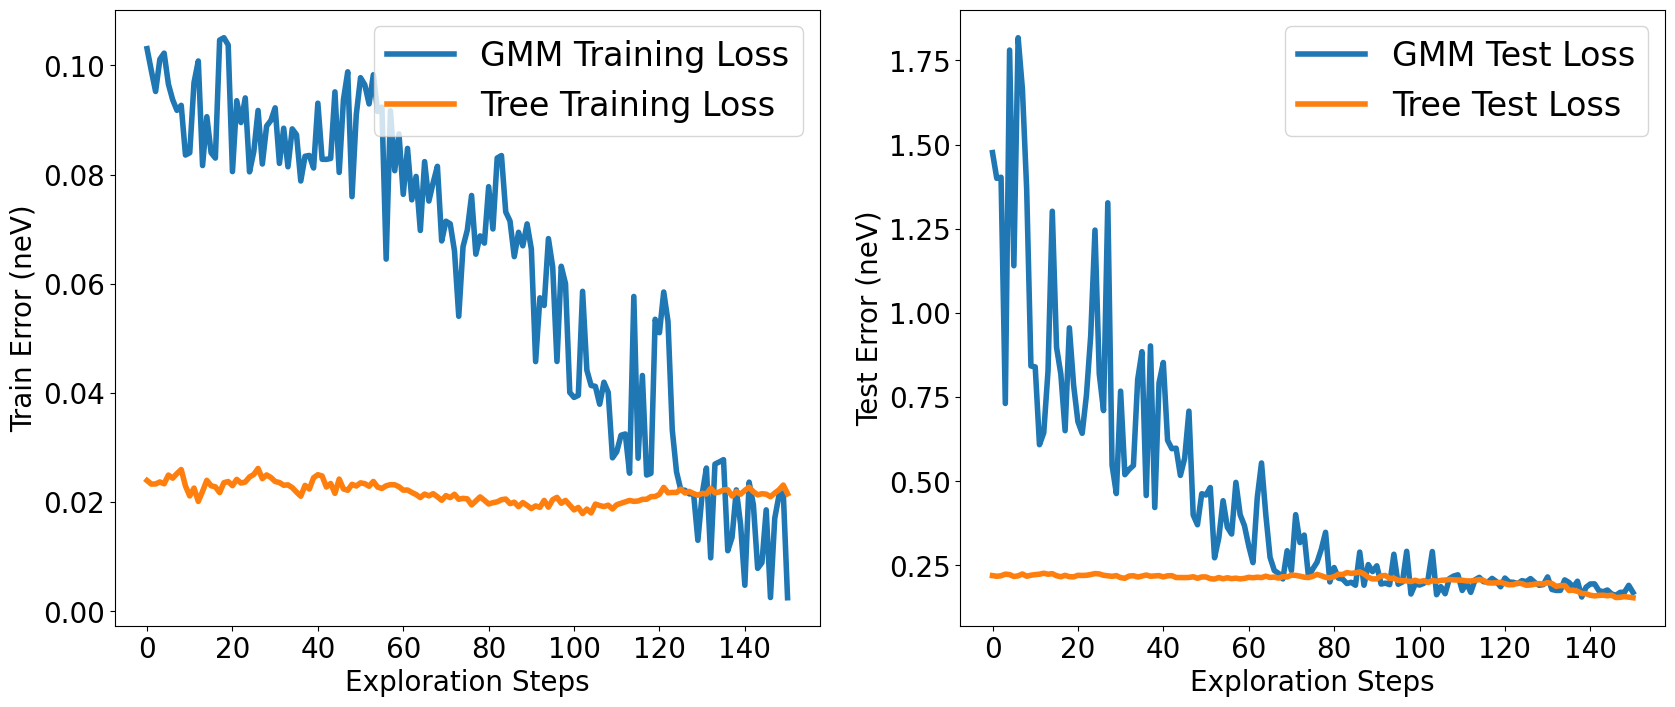

In [68]:
plt.figure(figsize=(14, 10))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax[0].plot(np.array([val/1e-9 for val in gmm_training_loss[::-1]]), label='GMM Training Loss',linewidth=4)
ax[1].plot(np.array([val/1e-9 for val in gmm_test_loss]), label='GMM Test Loss', linewidth=4)

ax[0].plot(np.array([val/1e-9 for val in training_loss]), label='Tree Training Loss',linewidth=4)
ax[1].plot(np.array([val/1e-9 for val in test_loss]), label='Tree Test Loss',linewidth=4)
ax[0].set_xticks(range(0, num_iterations, 20))
ax[1].set_xticks(range(0, num_iterations, 20))
ax[0].set_xlabel('Exploration Steps', fontsize=20)
ax[1].set_xlabel('Exploration Steps',fontsize=20)
ax[0].set_ylabel('Train Error (neV)',fontsize=20)
ax[1].set_ylabel('Test Error (neV)',fontsize=20)

ax[0].legend(fontsize=24)
ax[1].legend(fontsize=24)
ax[0].tick_params(axis='both', which='major', labelsize=20)
ax[1].tick_params(axis='both', which='major', labelsize=20)




DKL

In [11]:
import dklgpreg, gptrain
def active_learning_single_tasks(task,image_mask,energy_to_ind,exploration_steps,acquisition, latent_features=None):
    # Split dataset into training and testing
    np.random.seed(42)
    torch.manual_seed(42)
    (X_train, X_test, y_train, y_test, iterations_train, iterations_test) = train_test_split(
                image_mask[task], energy_to_ind[task]["target_total_energy_per_atom"], energy_to_ind[task]['Iteration'], test_size=0.9, shuffle=False, random_state=12)

    datadim = 43264
    
    embedim = 2 
    num_iterations = exploration_steps
    num_samples_per_iteration = 1

    training_cycles = 20
    lr = 1e-1

    unlabeled_img = np.array(X_test)

    print("Unlabeled Image:",unlabeled_img.shape)
    # X_train = np.squeeze(X_train,axis=1)
    # X_test = np.squeeze(X_test,axis=1)
    
    s1,s2,s3 = X_train.shape
    X_train = X_train.reshape(-1,s2*s3)
    X_test = X_test.reshape(-1,s2*s3)
    
    y_train = np.array(y_train).reshape(1,-1)
    y_test = np.array(y_test).reshape(1,-1)

    true_labels = energy_to_ind[task]['target_total_energy_per_atom'] 

    train_x = torch.tensor(X_train, dtype = torch.float32)
    train_y = torch.tensor(np.array(y_train), dtype = torch.float32)
    test_x = torch.tensor(X_test, dtype = torch.float32)
    test_y = torch.tensor(np.array(y_test), dtype = torch.float32)

    target_labels = torch.tensor(np.array(energy_to_ind[task]['target_total_energy_per_atom'][iterations_test.index]),dtype=torch.float32)

    iterations_train = torch.tensor(np.array(iterations_train),dtype=torch.float32)
    iterations_test = torch.tensor(np.array(iterations_test),dtype=torch.float32)

    print(f"True labels shape: {true_labels.shape}")
    print(f"True labels indices: {true_labels.index}")

    acquisiton_function = {
        "uncertainty": select_most_uncertain_samples,
        "stability" : select_most_stable_energy_samples,
    }

    selected_iter = []
    selected_energy = []
    training_loss = []
    test_loss = []
    model_mod = torch.nn.Sequential(
                                    torch.nn.Linear(datadim,2048),
                                    torch.nn.ReLU(),
                                    # torch.nn.Linear(10240,2048),
                                    # torch.nn.ReLU(),
                                    torch.nn.Linear(2048,1024),
                                    torch.nn.ReLU(),
                                    torch.nn.Linear(1024, 256),
                                    torch.nn.ReLU(),
                                    *(list(fcFeatureExtractor(256,embedim).children())),)

    dklgp = dklgpreg.dklGPR(datadim,embedim,hidden_dim=[1000,500,50],feature_extract=copy.deepcopy(model_mod),precision="single")#aoi.models.dklGPR(data_dim, embedim=2, precision="double")
    mse_loss_training = []
    mse_loss_test = []
    rmse = torch.nn.MSELoss()
    for iteration in range(num_iterations):

        print(f"Iteration {iteration+1}/{num_iterations}")
        start = time.time()
        dklgp.fit(train_x, train_y, training_cycles=training_cycles, lr=lr)
        end = time.time()
        print("Time taken to fit the model:", end-start)
        mean, var = dklgp.predict(test_x)
        #most_uncertain_index = select_most_uncertain_samples(dklgp, test_x, num_samples=num_samples_per_iteration)
        most_uncertain_index = acquisiton_function[acquisition](var, num_samples=num_samples_per_iteration)
        print(f"Most uncertain indices: {most_uncertain_index}")
        pred_train = torch.tensor(dklgp.predict(train_x)[0])
        pred_test = torch.tensor(dklgp.predict(test_x)[0])
        
        train_loss = torch.sqrt(rmse(pred_train.reshape(-1,),train_y.reshape(-1,))).item()
        training_loss.append(train_loss)
        testloss = torch.sqrt(rmse(pred_test.reshape(-1,),test_y.reshape(-1,))).item()
        test_loss.append(testloss)
        unlabelled_images = [unlabeled_img[i] for i in most_uncertain_index]

        selected_iter.append(iterations_test[most_uncertain_index.cpu().numpy()].cpu().numpy())
        selected_energy.append(target_labels[most_uncertain_index.cpu().numpy()].cpu().numpy())

        plot_images_by_indices(unlabelled_images, most_uncertain_index.cpu().numpy(), target_labels.cpu().numpy(), iterations_test.cpu().numpy(), task, iteration, acquisition, cols=num_samples_per_iteration)

        if iteration in [5, 100, 150, 440]:
            print("Total time taken for active learning:", iteration*(end-start))
            
            mod_plot_selected_points(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
            # mod_plot_selected_points_gif(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
            hist_test_y = np.array([val/1e-6 for val in test_y.cpu().numpy()]).reshape(-1,)
            hist_mu_y = np.array([val/1e-6 for val in pred_test.cpu().numpy()])

            # #Plot Training Loss
            # tree_mod_plot_al_training_loss(test_loss,task,num_iterations,acquisition)
            plt.hist(hist_mu_y, bins=10, alpha=0.6, color='coral', label=f'Predicted Energy - Exp Step{iteration}')
            plt.hist(hist_test_y, bins=10, alpha=0.5, label='True Energy', color="seagreen")
            plt.title(f'Energy Distribution for Task {task+1} - Active Learning Exploration')
            plt.xlabel('Energy (ueV)')
            plt.ylabel('Frequency')
            plt.legend()
            # plt.savefig(f"{cwd_path}/results/tree_regressor/active_learning/energy_distribution_task{task+1}_exp_steps{iteration}.png")
            plt.show(block=True)
            plt.clf()
            
            plt.figure(figsize=(10, 6))
            # plt.scatter(iterations_train, y_train, c='r', marker='*', alpha=0.5, label="Train - True")
            # plt.scatter(iterations_train, y_mean, c="b", marker='*', alpha=0.5, label="Train - Predicted")
            # plt.scatter(iterations_train, train_prediction_variance, color='green',  marker='*', alpha=0.5, label="Train Variance")
            print(iterations_test.shape, hist_test_y.shape, hist_mu_y.shape)
            plt.scatter(iterations_test.cpu().numpy(), hist_test_y, c='r', marker='D', alpha=0.5, label="Test - True")
            plt.scatter(iterations_test.cpu().numpy(), hist_mu_y, c="b", marker='D', alpha=0.5, label="Test - Predicted")
            # plt.scatter(iterations_test, prediction_variance, color='green', marker="D",alpha=0.5, label="Test Variance")
            plt.xlabel('Iterations')
            plt.ylabel('True vs Predicted Energy Difference per Atom (ueV)')
            plt.title('True vs Predicted Energy Values for Task ' + str(task+1) + " after {} iterations".format(num_iterations))
            plt.legend()
            # plt.savefig(f"{cwd_path}/results/GMM/active_learning/regression_true_vs_predicted_task{task+1}_exp_steps{iteration}.png")
            plt.show(block=True)
            plt.clf()

        if iteration == num_iterations-1:
            break
        
        train_x = torch.cat((train_x, test_x[most_uncertain_index.item()][None]), 0)
        train_y = torch.cat((train_y, test_y[:,most_uncertain_index.item()].reshape(1,-1)), 1)
        
        test_x = torch.cat((test_x[:most_uncertain_index.item()], test_x[most_uncertain_index.item()+1:]), 0)
        test_y = torch.cat((test_y[:,:most_uncertain_index.item()].reshape(1,-1), test_y[:,most_uncertain_index.item()+1:].reshape(1,-1)), 1)
        
        unlabeled_img = np.concatenate((unlabeled_img[:most_uncertain_index.item()], unlabeled_img[most_uncertain_index.item()+1:]), 0)
        target_labels = torch.cat((target_labels[:most_uncertain_index.item()], target_labels[most_uncertain_index.item()+1:]), 0)
        
        iterations_test = torch.cat((iterations_test[:most_uncertain_index.item()], iterations_test[most_uncertain_index.item()+1:]), 0)
        
        
        mse_loss_training.append(train_loss)
        mse_loss_test.append(test_loss)

        print(f"New data shape: {train_x.shape}")
        print(f"New data label: {train_y.shape}")
        # torch.save(dklgp,f"results/single_tasks/active_learning/task{task+1}/AL_exp{iteration}_with_{acquisition}_acq_model.pt")
    
    #plot_selected_points(iterations_test,test_y,selected_iter,selected_energy,acquisition,task,num_iterations)
    # mod_plot_selected_points(iterations_test, test_y, selected_iter, selected_energy, acquisition, task, num_iterations)
    
    #Plot Training Loss
    # mod_plot_al_training_loss(training_loss,task,num_iterations,acquisition)

    # print("Train MSE:",np.mean(mse_loss_training)/1e-3)
    # print("Test MSE:",np.mean(mse_loss_test)/1e-3)
    
    return selected_energy, selected_iter, training_loss, test_loss, iterations_test,test_y, acquisition,task, num_iterations
task = 1
selected_energy, selected_iter, dkl_training_loss, dkl_test_loss, iterations_test,test_y, acquisition,task, num_iterations = active_learning_single_tasks(task, cropped_image_list, energy_to_ind, 441, "uncertainty", latent_features)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


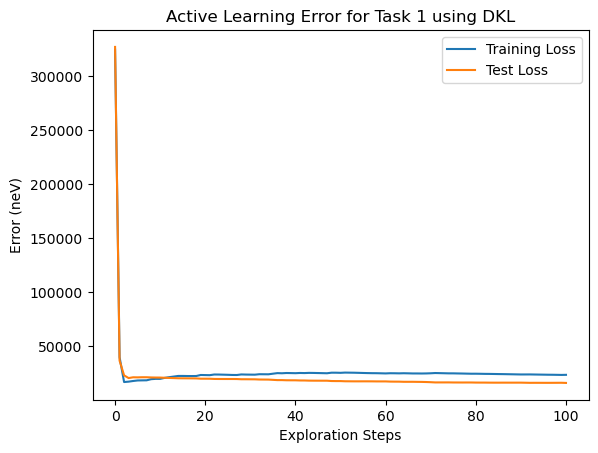

In [84]:
plt.plot(np.array([val/1e-9 for val in dkl_training_loss]), label='Training Loss')
plt.plot(np.array([val/1e-9 for val in dkl_test_loss]), label='Test Loss')
plt.legend()
plt.xlabel('Exploration Steps')
plt.ylabel('Error (neV)')
plt.title('Active Learning Error for Task 1 using DKL')
plt.show()


<Figure size 1200x800 with 0 Axes>

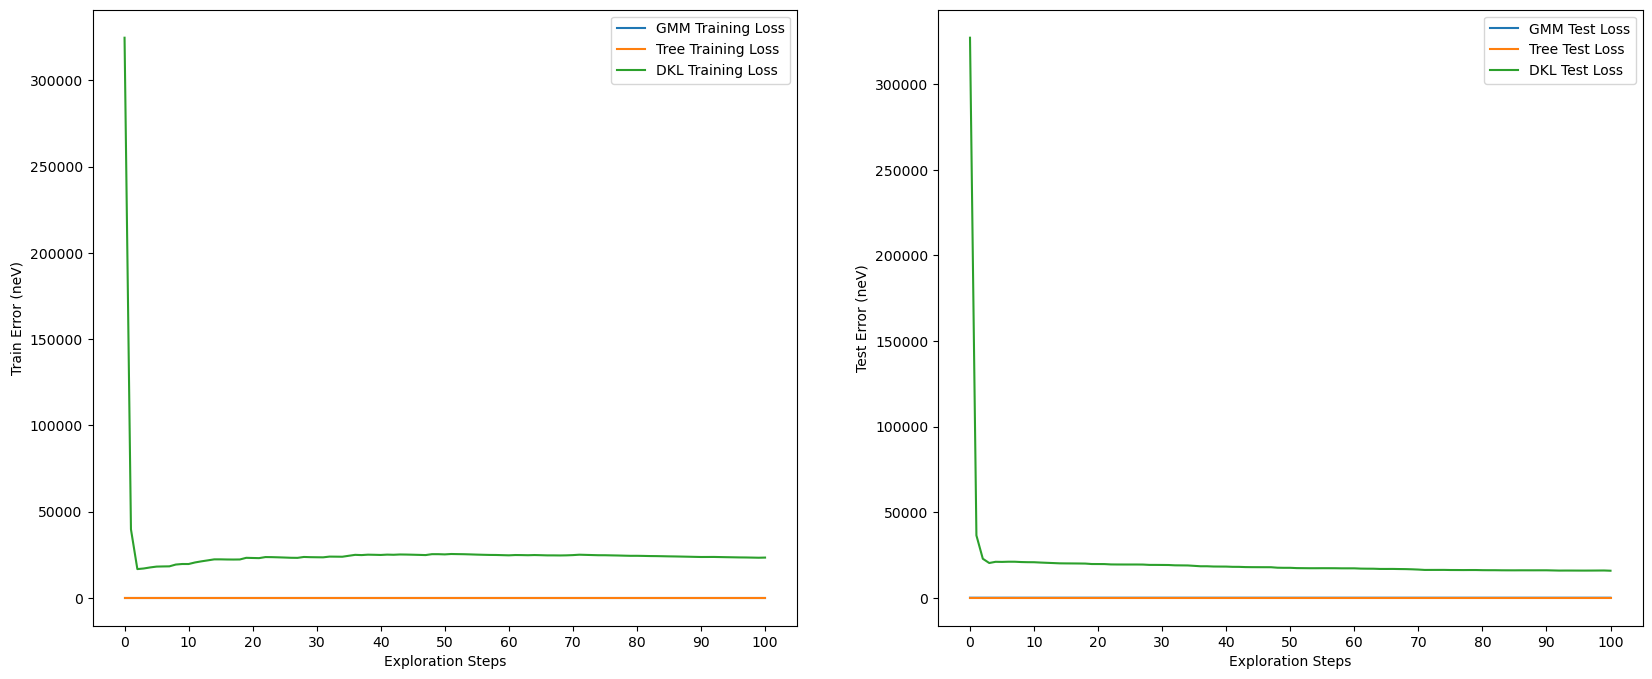

In [82]:
plt.figure(figsize=(12, 8))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax[0].plot(np.array([val/1e-9 for val in gmm_training_loss[::-1]]), label='GMM Training Loss')
ax[1].plot(np.array([val/1e-9 for val in gmm_test_loss]), label='GMM Test Loss')
ax[0].plot(np.array([val/1e-9 for val in training_loss[:101]]), label='Tree Training Loss')
ax[1].plot(np.array([val/1e-9 for val in test_loss[:101]]), label='Tree Test Loss')
ax[0].plot(np.array([val/1e-9 for val in dkl_training_loss]), label='DKL Training Loss')
ax[1].plot(np.array([val/1e-9 for val in dkl_test_loss]), label='DKL Test Loss')
ax[0].set_xticks(range(0, num_iterations, 10))
ax[1].set_xticks(range(0, num_iterations, 10))
ax[0].set_xlabel('Exploration Steps')
ax[1].set_xlabel('Exploration Steps')
ax[0].set_ylabel('Train Error (neV)')
ax[1].set_ylabel('Test Error (neV)')

ax[0].legend()
ax[1].legend()




#### Miscellaneous

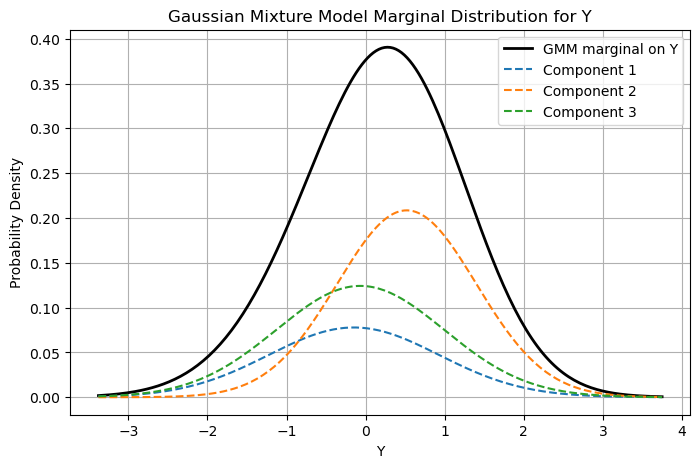

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# After fitting your GMM:
# gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
# gmm.fit(XY)

# Extract GMM parameters
means = gmm.means_          # shape: (n_components, 33)
covariances = gmm.covariances_  # shape: (n_components, 33, 33)
weights = gmm.weights_

# The Y dimension is the last one, i.e., index -1
y_means = means[:, -1]            # shape: (n_components,)
y_variances = covariances[:, -1, -1]  # each component's variance for Y
y_stds = np.sqrt(y_variances)

# Define a range for Y values to plot over
y_min = y_means.min() - 3 * y_stds.max()
y_max = y_means.max() + 3 * y_stds.max()
y = np.linspace(y_min, y_max, 200)

# Compute the marginal PDF for Y by summing component PDFs
y_pdf = np.zeros_like(y)
for k in range(gmm.n_components):
    # For each component, compute the 1D Gaussian PDF at points y
    component_pdf = norm.pdf(y, loc=y_means[k], scale=y_stds[k])
    # Weight it by the component's mixing weight and add to total
    y_pdf += weights[k] * component_pdf

# Plot the mixture's marginal PDF over Y
plt.figure(figsize=(8,5))
plt.plot(y, y_pdf, label='GMM marginal on Y', color='black', linewidth=2)

# Optionally, plot each component separately
for k in range(gmm.n_components):
    component_pdf = norm.pdf(y, loc=y_means[k], scale=y_stds[k])
    plt.plot(y, weights[k] * component_pdf, '--', label=f'Component {k+1}')

plt.title('Gaussian Mixture Model Marginal Distribution for Y')
plt.xlabel('Y')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

def KL(P,Q):
     """ Epsilon is used here to avoid conditional code for
     checking that neither P nor Q is equal to 0. """
     epsilon = 0.00001
     
     # You may want to instead make copies to avoid changing the np arrays.
     P = P+epsilon
     Q = Q+epsilon

     divergence = np.sum(P*np.log(P/Q))
     return divergence

print(KL(y_test, mu_y))

[[ 0.36909111]
 [ 0.86311955]
 [ 0.02061752]
 [ 1.56981296]
 [        nan]
 [        nan]
 [ 1.37564242]
 [-0.66712301]
 [ 0.95893987]
 [ 0.99243938]
 [ 1.04506462]
 [-0.99963175]
 [ 0.5946424 ]
 [-0.03823907]
 [-1.55630665]
 [ 1.45756403]
 [ 1.07469473]
 [ 0.35067521]
 [        nan]
 [ 0.60202326]
 [        nan]
 [-0.33553278]
 [        nan]
 [ 0.40110989]
 [-1.7388155 ]
 [        nan]
 [-0.12634292]
 [        nan]
 [-0.20550132]
 [-0.36427181]
 [ 0.64972687]
 [        nan]
 [        nan]
 [ 0.48593403]
 [ 0.65305964]
 [-0.33929846]
 [        nan]
 [ 1.01324405]
 [-0.2832782 ]
 [-0.3101384 ]
 [        nan]
 [        nan]
 [ 0.468547  ]
 [ 1.24497849]
 [        nan]
 [        nan]
 [ 2.64390117]
 [-2.07216345]
 [-0.97091703]
 [ 0.82931212]
 [        nan]
 [-0.62658241]
 [        nan]
 [ 0.85529169]
 [ 0.15288158]
 [ 0.15328942]
 [-0.11095305]
 [        nan]
 [-1.44717028]
 [        nan]
 [-0.29142984]
 [        nan]
 [ 1.76947655]
 [-1.12554065]
 [        nan]
 [ 1.68316661]
 [ 0.76806

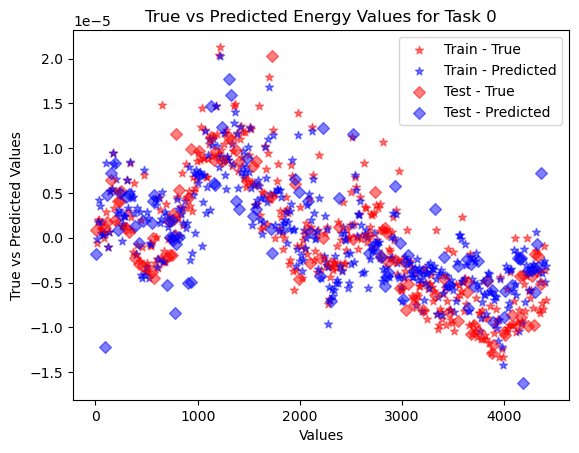

In [10]:
if plot_regression == True:
        # Optional: Plotting Predicted vs True Values
        plt.scatter(iterations_train,y_train, c='r', marker='*', alpha=0.5, label="Train - True")
        plt.scatter(iterations_train, Y_means, c="b", marker='*', alpha=0.5, label="Train - Predicted")
        plt.scatter(iterations_test,y_test, c='r', marker='D', alpha=0.5, label="Test - True")
        plt.scatter(iterations_test, mu_y, c="b", marker='D', alpha=0.5, label="Test - Predicted")
        plt.xlabel('Values')
        plt.ylabel('True vs Predicted Values')
        plt.title('True vs Predicted Energy Values for Task ' + str(task))
        plt.legend()
        plt.show()